In [1]:
####################### Comparison Cross Sections ##########################
# Plot cross sections comparing mixing (physical and numerical) for
# the different vertical (and eventually horizontal) advection schemes
# at certain snapshots in time. Plot the actual values for one of the 
# setups and then the different for the others. Also consider adding 
# in mixed layer deepth.
#
# Notes:
# - This script runs in xroms 
# - This script heavily uses code from Dylan Schlichting 
# - 
#
##############################################################################

In [2]:
# Load in the packages
import numpy as np
import cartopy
import glob
import cartopy.crs as ccrs
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import cartopy.feature as cfeature
import cmocean.cm as cmo
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm
import matplotlib.ticker as tick
import warnings
import matplotlib.colors as colors
import xarray as xr
import xroms
from matplotlib import ticker
crs = ccrs.PlateCarree()
warnings.filterwarnings("ignore") #turns off annoying warnings
#Cartopy
land_10m = cfeature.NaturalEarthFeature('physical', 'land', '10m',
                                edgecolor='face',
                                facecolor=cfeature.COLORS['land'])

# The core of the analysis is done with xhistogram
from xhistogram.xarray import histogram

## Define Functions  
Define a bunch of functions to help with processing the output

In [3]:
# Make a function to open the model output
def open_roms(path):
    '''
Opens multiple netcdf files with xroms
    '''
    # chunk = {"xi": -1, "eta": -1, "ocean_time": -1} 
    # chunks = {}
    # for sub in ["rho", "u", "v", "psi"]:
        # for k, v in chunk.items():
            # chunks[f"{k}_{sub}"] = v
    # chunks["ocean_time"] = chunk["ocean_time"]

    ds = xroms.open_netcdf(path)
    ds,grid = xroms.roms_dataset(ds,include_cell_volume=True)
    ds.xroms.set_grid(grid)
    return ds,grid

In [4]:
def open_mfroms(path):
    '''
Opens multiple netcdf files with xroms
    '''
    # chunk = {"xi": -1, "eta": -1, "ocean_time": -1} 
    # chunks = {}
    # for sub in ["rho", "u", "v", "psi"]:
        # for k, v in chunk.items():
            # chunks[f"{k}_{sub}"] = v
    # chunks["ocean_time"] = chunk["ocean_time"]

    ds = xroms.open_mfnetcdf(path)
    ds,grid = xroms.roms_dataset(ds,include_cell_volume=True)
    ds.xroms.set_grid(grid)
    return ds,grid

In [5]:
# Make a function to calculate useful derivatives and add them back into 
# the dataset
def add_derivatives(ds, grid, q='salt'):
    '''
Analysis of velocity gradient tensor and frontogenesis function
following Hetland et al. (2025) JPO
    '''
    qs = ds[q]
    
    #############################
    # Flow and property gradients at the ocean surface
    
    ds['dqdx'] = xroms.to_rho(grid.derivative(qs.isel(s_rho=-1), 'X'), grid)    # defined at rho-points
    ds['dqdy'] = xroms.to_rho(grid.derivative(qs.isel(s_rho=-1), 'Y'), grid)    # defined at rho-points
    
    ds['dudx'] = grid.derivative(ds.isel(s_rho=-1).u, 'X', boundary='extend')  # defined at rho-points
    ds['dvdy'] = grid.derivative(ds.isel(s_rho=-1).v, 'Y', boundary='extend')  # defined at rho-points
    ds['dvdx'] = xroms.to_rho(grid.derivative(ds.isel(s_rho=-1).v, 'X', boundary='extend'), grid)  # defined at rho-points
    ds['dudy'] = xroms.to_rho(grid.derivative(ds.isel(s_rho=-1).u, 'Y', boundary='extend'), grid)  # defined at rho-points
    
    ###########################
    # Invariant flow properties
    
    # Vorticity:  v_x - u_y
    ds['zeta'] = (ds.dvdx - ds.dudy)/ds.f
    ds['zeta'].name = 'Normalized vorticity'

    # Divergence: u_x + v_y
    ds['delta'] = (ds.dudx + ds.dvdy)/ds.f
    ds['delta'].name = 'Normalized divergence'

    # Major axis of deformation
    ds['alpha'] = ( np.sqrt( (ds.dudx-ds.dvdy)**2 + (ds.dvdx+ds.dudy)**2 ) )/ds.f
    ds['alpha'].name = 'Normalized total strain'

    ##################################
    # Principle deformation components

    ds['lminor'] = 0.5 * (ds.delta - ds.alpha)
    ds['lminor'].name = 'lambda minor'

    ds['lmajor'] = 0.5 * (ds.delta + ds.alpha)
    ds['lmajor'].name = 'lambda major'
    
    #############################################
    # Along- and cross-frontal velocity gradients
    
    # angle is wrt x, so need to do arctan2(y, x)
    ds['phi_cf'] = np.arctan2(ds.dqdy, ds.dqdx)
    ds['phi_af'] = ds.phi_cf + np.pi/2.0

    ds['du_cf'] = ( ds.dudx*np.cos(ds.phi_cf)**2 + ds.dvdy*np.sin(ds.phi_cf)**2 
               + (ds.dudy + ds.dvdx)*np.sin(ds.phi_cf)*np.cos(ds.phi_cf) )/ds.f

    ds['du_af'] = ( ds.dudx*np.cos(ds.phi_af)**2 + ds.dvdy*np.sin(ds.phi_af)**2
              + (ds.dudy + ds.dvdx)*np.sin(ds.phi_af)*np.cos(ds.phi_af) )/ds.f
    
    ############################
    # The frontogenesis function
    
    # Dimensional frontogenesis function
    Dgradq_i = - ds.dudx*ds.dqdx - ds.dvdx*ds.dqdy
    Dgradq_j = - ds.dudy*ds.dqdx - ds.dvdy*ds.dqdy
    ds['Ddelq2'] = (ds.dqdx*Dgradq_i + ds.dqdy*Dgradq_j)
    ds['Ddelq2'].name = 'Frontogenesis function'

    # Density gradients squared
    ds['gradq2'] = ds.dqdx**2 + ds.dqdy**2
    ds['gradq2'].name = r'$(\nabla q)^2$'

    # Normalized frontogenesis function
    ds['nFGF'] = 0.5 * ds.Ddelq2 / (ds.gradq2 * ds.f)
    ds['nFGF'].name = r'Normalized Frontogenesis Function'
    
    return ds

## Post-Processing  
Load in and process the model output

In [6]:
# Set the path to the desired model output

# Constant forcing (time series), ice, U3C4, K-eps
#path = glob.glob('/global/cfs/cdirs/m4572/dylan617/beaufort_jet/runs/roms_avg_ice_500m_w_dvd_constant_forcing_u3c4_keps*.nc')

# ----- Vertical Mixing Schemes ------
# Constant forcing, U3C4, k-epsilon
grd_file = '/global/homes/b/bundzis/Projects/Beaufort_ROMS_idealized_jet/Include/grd_1000_m.nc'
path_const_u3c4_keps = glob.glob('/global/cfs/cdirs/m4572/dylan617/beaufort_jet/runs/roms_avg_ice_500m_w_dvd_constant_forcing_u3c4_keps_*.nc')
# Constant forcing, U3C4, gen
# grd_file = '/global/homes/b/bundzis/Projects/Beaufort_ROMS_idealized_jet/Include/grd_1000_m.nc'
path_const_u3c4_gen = glob.glob('/global/cfs/cdirs/m4572/dylan617/beaufort_jet/runs/roms_avg_ice_500m_w_dvd_constant_forcing_u3c4_gen_*.nc')
# Constant forcing, U3C4, kkl
# grd_file = '/global/homes/b/bundzis/Projects/Beaufort_ROMS_idealized_jet/Include/grd_1000_m.nc'
path_const_u3c4_kkl = glob.glob('/global/cfs/cdirs/m4572/dylan617/beaufort_jet/runs/roms_avg_ice_500m_w_dvd_constant_forcing_u3c4_kkl_*.nc')
# Constant forcing, U3C4, k-omega
# grd_file = '/global/homes/b/bundzis/Projects/Beaufort_ROMS_idealized_jet/Include/grd_1000_m.nc'
path_const_u3c4_komega = glob.glob('/global/cfs/cdirs/m4572/dylan617/beaufort_jet/runs/roms_avg_ice_500m_w_dvd_constant_forcing_u3c4_komega_*.nc')
# Constant forcing, U3C4, kpp
# grd_file = '/global/homes/b/bundzis/Projects/Beaufort_ROMS_idealized_jet/Include/grd_1000_m.nc'
path_const_u3c4_kpp = glob.glob('/global/cfs/cdirs/m4572/dylan617/beaufort_jet/runs/roms_avg_ice_500m_w_dvd_constant_forcing_u3c4_kpp_*.nc')

In [7]:
# Load in the different outputs 

# ----- Vertical Mixing Schemes ------
# Constant forcing, U3C4, k-epsilon
ds_const_u3c4_keps, grid_const_u3c4_keps = open_mfroms(path_const_u3c4_keps)
add_derivatives(ds_const_u3c4_keps, grid_const_u3c4_keps)
# Constant forcing, U3C4, gen
ds_const_u3c4_gen, grid_const_u3c4_gen = open_mfroms(path_const_u3c4_gen)
add_derivatives(ds_const_u3c4_gen, grid_const_u3c4_gen)
# Constant forcing, U3C4, kkl
ds_const_u3c4_kkl, grid_const_u3c4_kkl = open_mfroms(path_const_u3c4_kkl)
add_derivatives(ds_const_u3c4_kkl, grid_const_u3c4_kkl)
# Constant forcing, U3C4, k-omega
ds_const_u3c4_komega, grid_const_u3c4_komega = open_mfroms(path_const_u3c4_komega)
add_derivatives(ds_const_u3c4_komega, grid_const_u3c4_komega)
# Constant forcing, U3C4, kpp
ds_const_u3c4_kpp, grid_const_u3c4_kpp = open_mfroms(path_const_u3c4_kpp)
add_derivatives(ds_const_u3c4_kpp, grid_const_u3c4_kpp)

<xarray.Dataset> Size: 4TB
Dimensions:             (tracer: 8, s_rho: 40, s_w: 41, eta_rho: 1002,
                         xi_rho: 402, eta_v: 1001, xi_u: 401, ocean_time: 1104)
Coordinates: (12/21)
  * s_rho               (s_rho) float64 320B -0.9875 -0.9625 ... -0.0375 -0.0125
  * s_w                 (s_w) float64 328B -1.0 -0.975 -0.95 ... -0.025 0.0
    x_rho               (eta_rho, xi_rho) float64 3MB dask.array<chunksize=(1002, 402), meta=np.ndarray>
    y_rho               (eta_rho, xi_rho) float64 3MB dask.array<chunksize=(1002, 402), meta=np.ndarray>
    x_u                 (eta_rho, xi_u) float64 3MB dask.array<chunksize=(1002, 401), meta=np.ndarray>
    y_u                 (eta_rho, xi_u) float64 3MB dask.array<chunksize=(1002, 401), meta=np.ndarray>
    ...                  ...
    z_w_v               (ocean_time, s_w, eta_v, xi_rho) float64 146GB dask.array<chunksize=(1, 41, 1001, 402), meta=np.ndarray>
    z_w_psi             (ocean_time, s_w, eta_v, xi_u) float64 145GB dask.array<chunksize=(1, 41, 1001, 401), meta=np.ndarray>
    z_rho               (ocean_time, s_rho, eta_rho, xi_rho) float64 142GB dask.array<chunksize=(1, 40, 1002, 402), meta=np.ndarray>
    z_rho_u             (ocean_time, s_rho, eta_rho, xi_u) float64 142GB dask.array<chunksize=(1, 40, 1002, 401), meta=np.ndarray>
    z_rho_v             (ocean_time, s_rho, eta_v, xi_rho) float64 142GB dask.array<chunksize=(1, 40, 1001, 402), meta=np.ndarray>
    z_rho_psi           (ocean_time, s_rho, eta_v, xi_u) float64 142GB dask.array<chunksize=(1, 40, 1001, 401), meta=np.ndarray>
Dimensions without coordinates: tracer
Data variables: (12/150)
    ntimes              int32 4B ...
    ndtfast             int32 4B ...
    dt                  float64 8B ...
    dtfast              float64 8B ...
    dstart              object 8B ...
    nHIS                int32 4B ...
    ...                  ...
    phi_af              (ocean_time, eta_rho, xi_rho) float64 4GB dask.array<chunksize=(1, 1002, 402), meta=np.ndarray>
    du_cf               (ocean_time, eta_rho, xi_rho) float64 4GB dask.array<chunksize=(1, 1002, 402), meta=np.ndarray>
    du_af               (ocean_time, eta_rho, xi_rho) float64 4GB dask.array<chunksize=(1, 1002, 402), meta=np.ndarray>
    Ddelq2              (ocean_time, eta_rho, xi_rho) float64 4GB dask.array<chunksize=(1, 1002, 402), meta=np.ndarray>
    gradq2              (ocean_time, eta_rho, xi_rho) float64 4GB dask.array<chunksize=(1, 1002, 402), meta=np.ndarray>
    nFGF                (ocean_time, eta_rho, xi_rho) float64 4GB dask.array<chunksize=(1, 1002, 402), meta=np.ndarray>
Attributes: (12/29)
    file:              /global/cfs/cdirs/m4572/dylan617/beaufort_jet/runs/rom...
    format:            netCDF-3 64bit offset file
    Conventions:       CF-1.4, SGRID-0.3
    type:              ROMS nonlinear model averages file
    title:             Idealized Alaskan beaufort shelf sea jet
    var_info:          /pscratch/sd/d/dylan617/roms/ROMS/External/varinfo.yaml
    ...                ...
    compiler_command:  /opt/cray/pe/mpich/8.1.30/ofi/gnu/12.3/bin/mpif90
    compiler_flags:    -frepack-arrays -mcmodel=large -fallow-argument-mismat...
    tiling:            16x32
    history:           ROMS, Version 4.3, Wednesday - December 31, 2025 -  7:...
    ana_file:          /global/homes/d/dylan617/beaufort_jet/project/Function...
    CPP_options:       BEAUFORT_JET_ICE_BULK_FLUXES_W_DVD, ANA_BPFLUX, ANA_BS...

In [8]:
# Calculate distance in km
# to use for plotting 
# Can use x_rho, y_rho, x_u, y_u, etc. but those are a 
# little wonky...sooooo calculate it yourself I guess
# (I think if we read in the grid directly then they will
# be fixed? but are weird in the output? No clue but do manually
# for now)
dx = ds_const_u3c4_keps.x_rho[0,2].values - ds_const_u3c4_keps.x_rho[0,1].values
print('dx: ', dx)
dy = ds_const_u3c4_keps.y_rho[1,0].values - ds_const_u3c4_keps.y_rho[0,0].values
print('dy: ', dy)

len_xi_rho = len(ds_const_u3c4_keps.xi_rho.values)
print('len_xi_rho: ' , len_xi_rho)
len_eta_rho = len(ds_const_u3c4_keps.eta_rho)
print('len_eta_rho: ', len_eta_rho)

x_rho = np.arange(0, len_xi_rho*dx, dx)
print('x_rho: ', x_rho[-10:-1])
print('ds_const_u3c4_keps.x_rho: ', ds_const_u3c4_keps.x_rho[0,-10:-1].values)

y_rho = np.arange(0, len_eta_rho*dy, dy)
print('y_rho: ', y_rho[-10:-1])
print('ds_const_u3c4_keps.y_rho: ', ds_const_u3c4_keps.y_rho[-10:-1,0].values)

x_u = x_rho[:-1]
y_u = np.copy(y_rho)
x_v = np.copy(x_rho)
y_v = y_rho[:-1]

dx:  500.0
dy:  500.0
len_xi_rho:  402
len_eta_rho:  1002
x_rho:  [196000. 196500. 197000. 197500. 198000. 198500. 199000. 199500. 200000.]
ds_const_u3c4_keps.x_rho:  [196000. 196500. 197000. 197500. 198000. 198500. 199000. 199500. 200000.]
y_rho:  [496000. 496500. 497000. 497500. 498000. 498500. 499000. 499500. 500000.]
ds_const_u3c4_keps.y_rho:  [496000. 496500. 497000. 497500. 498000. 498500. 499000. 499500. 500000.]


In [9]:
print(ds_const_u3c4_keps.rho0.values)
print(ds_const_u3c4_gen.rho0.values)
print(ds_const_u3c4_kkl.rho0.values)
print(ds_const_u3c4_komega.rho0.values)
print(ds_const_u3c4_kpp.rho0.values)
print(ds_const_u3c4_keps.Tcoef.values)
print(ds_const_u3c4_gen.Tcoef.values)
print(ds_const_u3c4_kkl.Tcoef.values)
print(ds_const_u3c4_komega.Tcoef.values)
print(ds_const_u3c4_kpp.Tcoef.values)
print(ds_const_u3c4_keps.Scoef.values)
print(ds_const_u3c4_gen.Scoef.values)
print(ds_const_u3c4_kkl.Scoef.values)
print(ds_const_u3c4_komega.Scoef.values)
print(ds_const_u3c4_kpp.Scoef.values)

1025.0
1025.0
1025.0
1025.0
1025.0
0.00017
0.00017
0.00017
0.00017
0.00017
0.00076
0.00076
0.00076
0.00076
0.00076


In [10]:
ds_const_u3c4_kpp

<xarray.Dataset> Size: 4TB
Dimensions:             (tracer: 8, s_rho: 40, s_w: 41, eta_rho: 1002,
                         xi_rho: 402, eta_v: 1001, xi_u: 401, ocean_time: 1104)
Coordinates: (12/21)
  * s_rho               (s_rho) float64 320B -0.9875 -0.9625 ... -0.0375 -0.0125
  * s_w                 (s_w) float64 328B -1.0 -0.975 -0.95 ... -0.025 0.0
    x_rho               (eta_rho, xi_rho) float64 3MB dask.array<chunksize=(1002, 402), meta=np.ndarray>
    y_rho               (eta_rho, xi_rho) float64 3MB dask.array<chunksize=(1002, 402), meta=np.ndarray>
    x_u                 (eta_rho, xi_u) float64 3MB dask.array<chunksize=(1002, 401), meta=np.ndarray>
    y_u                 (eta_rho, xi_u) float64 3MB dask.array<chunksize=(1002, 401), meta=np.ndarray>
    ...                  ...
    z_w_v               (ocean_time, s_w, eta_v, xi_rho) float64 146GB dask.array<chunksize=(1, 41, 1001, 402), meta=np.ndarray>
    z_w_psi             (ocean_time, s_w, eta_v, xi_u) float64 145GB dask.array<chunksize=(1, 41, 1001, 401), meta=np.ndarray>
    z_rho               (ocean_time, s_rho, eta_rho, xi_rho) float64 142GB dask.array<chunksize=(1, 40, 1002, 402), meta=np.ndarray>
    z_rho_u             (ocean_time, s_rho, eta_rho, xi_u) float64 142GB dask.array<chunksize=(1, 40, 1002, 401), meta=np.ndarray>
    z_rho_v             (ocean_time, s_rho, eta_v, xi_rho) float64 142GB dask.array<chunksize=(1, 40, 1001, 402), meta=np.ndarray>
    z_rho_psi           (ocean_time, s_rho, eta_v, xi_u) float64 142GB dask.array<chunksize=(1, 40, 1001, 401), meta=np.ndarray>
Dimensions without coordinates: tracer
Data variables: (12/150)
    ntimes              int32 4B ...
    ndtfast             int32 4B ...
    dt                  float64 8B ...
    dtfast              float64 8B ...
    dstart              object 8B ...
    nHIS                int32 4B ...
    ...                  ...
    phi_af              (ocean_time, eta_rho, xi_rho) float64 4GB dask.array<chunksize=(1, 1002, 402), meta=np.ndarray>
    du_cf               (ocean_time, eta_rho, xi_rho) float64 4GB dask.array<chunksize=(1, 1002, 402), meta=np.ndarray>
    du_af               (ocean_time, eta_rho, xi_rho) float64 4GB dask.array<chunksize=(1, 1002, 402), meta=np.ndarray>
    Ddelq2              (ocean_time, eta_rho, xi_rho) float64 4GB dask.array<chunksize=(1, 1002, 402), meta=np.ndarray>
    gradq2              (ocean_time, eta_rho, xi_rho) float64 4GB dask.array<chunksize=(1, 1002, 402), meta=np.ndarray>
    nFGF                (ocean_time, eta_rho, xi_rho) float64 4GB dask.array<chunksize=(1, 1002, 402), meta=np.ndarray>
Attributes: (12/29)
    file:              /global/cfs/cdirs/m4572/dylan617/beaufort_jet/runs/rom...
    format:            netCDF-3 64bit offset file
    Conventions:       CF-1.4, SGRID-0.3
    type:              ROMS nonlinear model averages file
    title:             Idealized Alaskan beaufort shelf sea jet
    var_info:          /pscratch/sd/d/dylan617/roms/ROMS/External/varinfo.yaml
    ...                ...
    compiler_command:  /opt/cray/pe/mpich/8.1.30/ofi/gnu/12.3/bin/mpif90
    compiler_flags:    -frepack-arrays -mcmodel=large -fallow-argument-mismat...
    tiling:            16x32
    history:           ROMS, Version 4.3, Wednesday - December 31, 2025 -  7:...
    ana_file:          /global/homes/d/dylan617/beaufort_jet/project/Function...
    CPP_options:       BEAUFORT_JET_ICE_BULK_FLUXES_W_DVD, ANA_BPFLUX, ANA_BS...

In [11]:
# Calculate density in the domain to use...or just
# for the transect if this causes the kernel to crash 
# Calculate density again but using linear equation of state 
# Set the coefficients/reference values from ROMS output
R0 = ds_const_u3c4_keps.rho0.values # kg/m3
T0 = 0.5 # Celsius
S0 =  31 # PSU/nondimensional
T_coeff = ds_const_u3c4_keps.Tcoef.values # 1/Celsius
S_coeff = ds_const_u3c4_keps.Scoef.values # 1/nondimensional

# Now calculate density
rho_const_u3c4_keps = R0 * (1 - (T_coeff*(ds_const_u3c4_keps.temp-T0)) + (S_coeff*(ds_const_u3c4_keps.salt-S0)))
rho_const_u3c4_gen = R0 * (1 - (T_coeff*(ds_const_u3c4_gen.temp-T0)) + (S_coeff*(ds_const_u3c4_gen.salt-S0)))
rho_const_u3c4_kkl = R0 * (1 - (T_coeff*(ds_const_u3c4_kkl.temp-T0)) + (S_coeff*(ds_const_u3c4_kkl.salt-S0)))
rho_const_u3c4_komega = R0 * (1 - (T_coeff*(ds_const_u3c4_komega.temp-T0)) + (S_coeff*(ds_const_u3c4_komega.salt-S0)))
rho_const_u3c4_kpp = R0 * (1 - (T_coeff*(ds_const_u3c4_kpp.temp-T0)) + (S_coeff*(ds_const_u3c4_kpp.salt-S0)))

In [12]:
# Set the transect locations (across-shelf)
x_tran1 = np.where(x_rho == 50000)
x_tran1 = int(x_tran1[0])
print(x_tran1)
x_tran2 = np.where(x_rho == 100000)
x_tran2 = int(x_tran2[0])
print(x_tran2)
x_tran3 =  np.where(x_rho == 150000)
x_tran3 = int(x_tran3[0])
print(x_tran3)

100
200
300


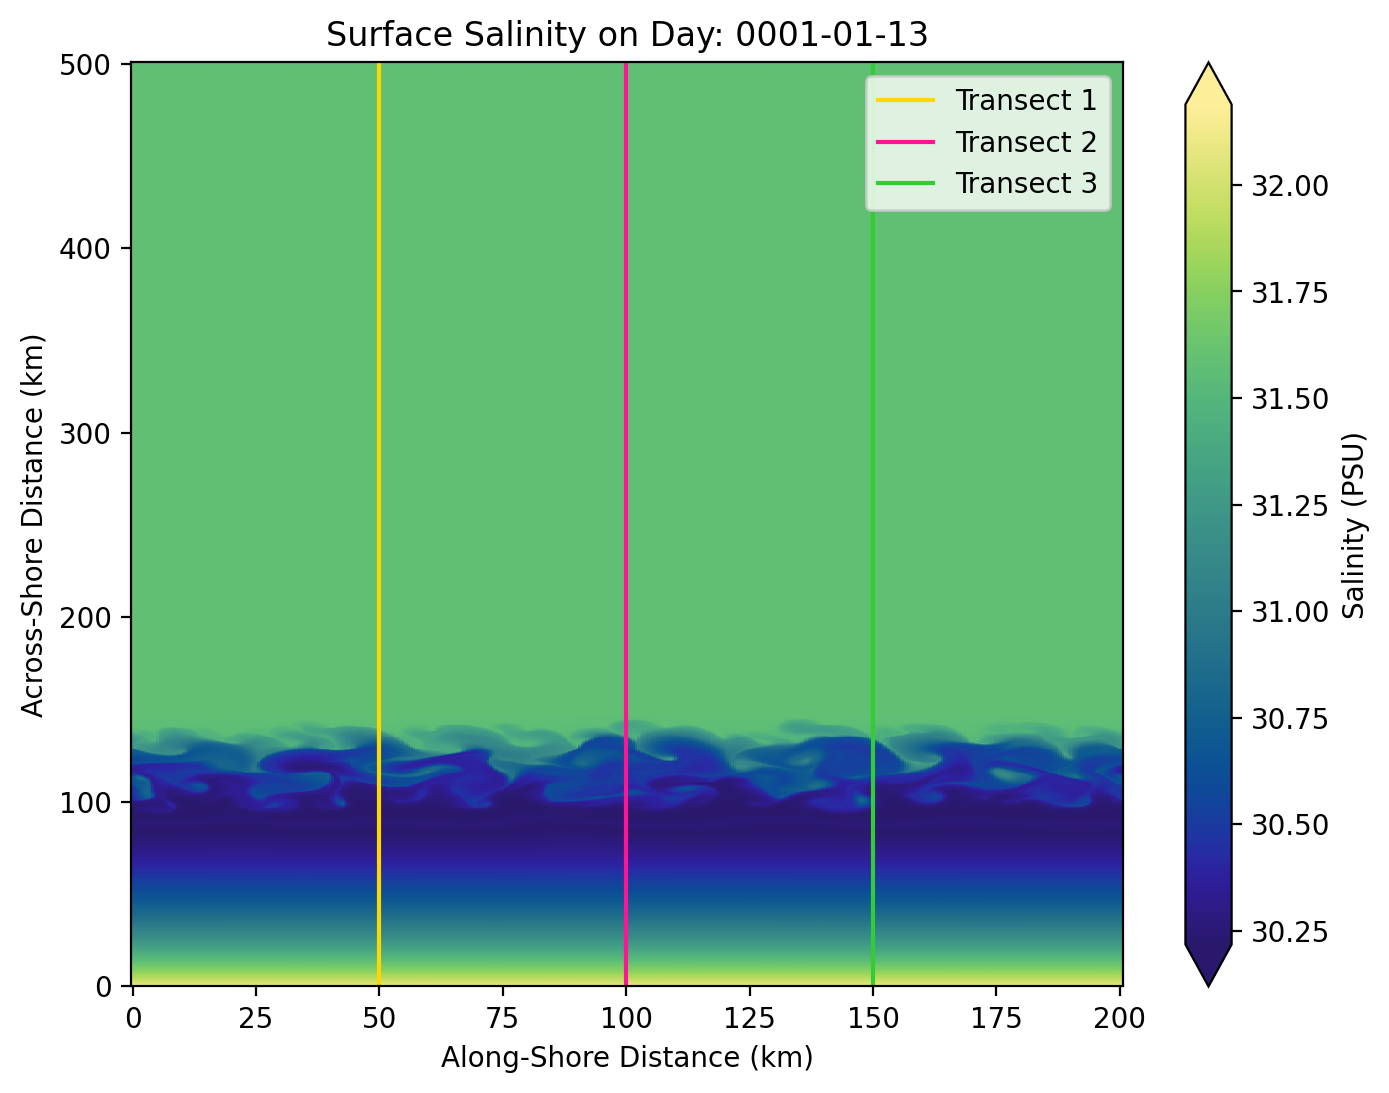

In [13]:
# Pick a time and transect 
# Plot the output to see different transect options 
# Plot the domain and pick the cross sections we want to look at 

# Set the time index to look at 
time_idx1 = 150

# Make the figure 
fig, ax  = plt.subplots(figsize=(8,6), dpi=200)

# Plot vorticity to pick our cross-sections 
p1 = ax.pcolormesh(x_rho/1000, y_rho/1000, ds_const_u3c4_keps.salt[time_idx1, -1, :, :],
               cmap=cmo.haline)

# Add a colorbar
fig.colorbar(p1, extend='both').set_label('Salinity (PSU)')

# Plot transects 
plt.axvline(x_rho[x_tran1]/1000, color='gold', linewidth=1.5, label='Transect 1')
plt.axvline(x_rho[x_tran2]/1000, color='deeppink', linewidth=1.5, label='Transect 2')
plt.axvline(x_rho[x_tran3]/1000, color='limegreen', linewidth=1.5, label='Transect 3')

# Label the axes
ax.set_xlabel('Along-Shore Distance (km)')
ax.set_ylabel('Across-Shore Distance (km)')
ax.set_title('Surface Salinity on Day: ' + str(ds_const_u3c4_keps.ocean_time.values[time_idx1])[:10])
ax.legend()

## Mixing  
Make cross-sections comparing mixing (physical and numerical) for salinity and temperature for the different runs with different vertical mixing schemes

In [14]:
# Set the time step 
# Pick the time to look at (one month in)
time_1mon = ds_const_u3c4_keps.ocean_time[168].values
print(time_1mon)
time_half_month = ds_const_u3c4_keps.ocean_time[372].values
print(time_half_month)

time_idx_half_month = 168
time_idx_1mon = 372

0001-01-15 01:00:00
0001-02-01 01:00:00


In [15]:
# Calculate mixing at a given time and transect for each run 
# Physical mixing
# Salinity (2-hourly)
# Constant forcing, U3C4, k-epsilon
Akr_rho_const_u3c4_keps = grid_const_u3c4_keps.interp(ds_const_u3c4_keps.AKr, 'Z')
mphys_tran1_1mon_const_u3c4_keps = (Akr_rho_const_u3c4_keps).isel(xi_rho=x_tran1, ocean_time=time_idx_1mon).compute()
#mphys = (Akr_rho*ds.dV).isel(eta_rho = eta_slice, xi_rho = xi_slice).sum(['eta_rho', 'xi_rho', 's_rho']).compute()
mphys_tran1_1mon_const_u3c4_keps.attrs = ''
# Constant forcing, U3C4, gen
Akr_rho_const_u3c4_gen = grid_const_u3c4_gen.interp(ds_const_u3c4_gen.AKr, 'Z')
mphys_tran1_1mon_const_u3c4_gen = (Akr_rho_const_u3c4_gen).isel(xi_rho=x_tran1, ocean_time=time_idx_1mon).compute()
mphys_tran1_1mon_const_u3c4_gen.attrs = ''
# Constant forcing, U3C4, kkl
Akr_rho_const_u3c4_kkl = grid_const_u3c4_kkl.interp(ds_const_u3c4_kkl.AKr, 'Z')
mphys_tran1_1mon_const_u3c4_kkl = (Akr_rho_const_u3c4_kkl).isel(xi_rho=x_tran1, ocean_time=time_idx_1mon).compute()
mphys_tran1_1mon_const_u3c4_kkl.attrs = ''
# Constant forcing, U3C4, k-omega
Akr_rho_const_u3c4_komega = grid_const_u3c4_kkl.interp(ds_const_u3c4_komega.AKr, 'Z')
mphys_tran1_1mon_const_u3c4_komega = (Akr_rho_const_u3c4_komega).isel(xi_rho=x_tran1, ocean_time=time_idx_1mon).compute()
mphys_tran1_1mon_const_u3c4_komega.attrs = ''
# Constant forcing, U3C4, kpp
Akr_rho_const_u3c4_kpp = grid_const_u3c4_kpp.interp(ds_const_u3c4_kpp.AKr, 'Z')
mphys_tran1_1mon_const_u3c4_kpp = (Akr_rho_const_u3c4_kpp).isel(xi_rho=x_tran1, ocean_time=time_idx_1mon).compute()
mphys_tran1_1mon_const_u3c4_kpp.attrs = ''

# Temperature (2-hourly)
# Constant forcing, U3C4, k-epsilon
Akrt_rho_const_u3c4_keps = grid_const_u3c4_keps.interp(ds_const_u3c4_keps.AKrt, 'Z')
mphyt_tran1_1mon_const_u3c4_keps = (Akrt_rho_const_u3c4_keps).isel(xi_rho=x_tran1, ocean_time=time_idx_1mon).compute()
mphyt_tran1_1mon_const_u3c4_keps.attrs = ''
# Constant forcing, U3C4, gen
Akrt_rho_const_u3c4_gen = grid_const_u3c4_gen.interp(ds_const_u3c4_gen.AKrt, 'Z')
mphyt_tran1_1mon_const_u3c4_gen = (Akrt_rho_const_u3c4_gen).isel(xi_rho=x_tran1, ocean_time=time_idx_1mon).compute()
mphyt_tran1_1mon_const_u3c4_gen.attrs = ''
# Constant forcing, U3C4, kkl
Akrt_rho_const_u3c4_kkl = grid_const_u3c4_kkl.interp(ds_const_u3c4_kkl.AKrt, 'Z')
mphyt_tran1_1mon_const_u3c4_kkl = (Akrt_rho_const_u3c4_kkl).isel(xi_rho=x_tran1, ocean_time=time_idx_1mon).compute()
mphyt_tran1_1mon_const_u3c4_kkl.attrs = ''
# Constant forcing, U3C4, k-omega
Akrt_rho_const_u3c4_komega = grid_const_u3c4_komega.interp(ds_const_u3c4_komega.AKrt, 'Z')
mphyt_tran1_1mon_const_u3c4_komega = (Akrt_rho_const_u3c4_komega).isel(xi_rho=x_tran1, ocean_time=time_idx_1mon).compute()
mphyt_tran1_1mon_const_u3c4_komega.attrs = ''
# Constant forcing, U3C4, kpp
Akrt_rho_const_u3c4_kpp = grid_const_u3c4_kpp.interp(ds_const_u3c4_kpp.AKrt, 'Z')
mphyt_tran1_1mon_const_u3c4_kpp = (Akrt_rho_const_u3c4_kpp).isel(xi_rho=x_tran1, ocean_time=time_idx_1mon).compute()
mphyt_tran1_1mon_const_u3c4_kpp.attrs = ''

In [16]:
# Calculate numerical mixing 
# Salinity 
# Constant forcing, U3C4, k-epsilon
mnum_salt_dv_tran1_1mon_const_u3c4_keps = (ds_const_u3c4_keps.dye_03).isel(xi_rho=x_tran1, ocean_time=time_idx_1mon).compute()
# Constant forcing, U3C4, gen
mnum_salt_dv_tran1_1mon_const_u3c4_gen = (ds_const_u3c4_gen.dye_03).isel(xi_rho=x_tran1, ocean_time=time_idx_1mon).compute()
# Constant forcing, U3C4, kkl
mnum_salt_dv_tran1_1mon_const_u3c4_kkl = (ds_const_u3c4_kkl.dye_03).isel(xi_rho=x_tran1, ocean_time=time_idx_1mon).compute()
# Constant forcing, U3C4, k-omega
mnum_salt_dv_tran1_1mon_const_u3c4_komega = (ds_const_u3c4_komega.dye_03).isel(xi_rho=x_tran1, ocean_time=time_idx_1mon).compute()
# Constant forcing, U3C4, kpp
mnum_salt_dv_tran1_1mon_const_u3c4_kpp = (ds_const_u3c4_kpp.dye_03).isel(xi_rho=x_tran1, ocean_time=time_idx_1mon).compute()

# Temperature
# Constant forcing, U3C4, k-epsilon
mnum_temp_dv_tran1_1mon_const_u3c4_keps = (ds_const_u3c4_keps.dye_06).isel(xi_rho=x_tran1, ocean_time=time_idx_1mon).compute()
# Constant forcing, U3C4, gen
mnum_temp_dv_tran1_1mon_const_u3c4_gen = (ds_const_u3c4_gen.dye_06).isel(xi_rho=x_tran1, ocean_time=time_idx_1mon).compute()
# Constant forcing, U3C4, kkl
mnum_temp_dv_tran1_1mon_const_u3c4_kkl = (ds_const_u3c4_kkl.dye_06).isel(xi_rho=x_tran1, ocean_time=time_idx_1mon).compute()
# Constant forcing, U3C4, k-omega
mnum_temp_dv_tran1_1mon_const_u3c4_komega = (ds_const_u3c4_komega.dye_06).isel(xi_rho=x_tran1, ocean_time=time_idx_1mon).compute()
# Constant forcing, U3C4, kpp
mnum_temp_dv_tran1_1mon_const_u3c4_kpp = (ds_const_u3c4_kpp.dye_06).isel(xi_rho=x_tran1, ocean_time=time_idx_1mon).compute()

In [17]:
# Constant forcing, U3C4, k-epsilon
# Constant forcing, U3C4, gen
# Constant forcing, U3C4, kkl
# Constant forcing, U3C4, k-omega
# Constant forcing, U3C4, kpp

In [37]:
# Is there a way to calculate mixed layer depth for just 
# the time/transect we want? Yes!
#dens_diff_const_u3c4_keps = (rho_const_u3c4_keps[time_idx_1mon,:,:,x_tran1] - rho_const_u3c4_keps[time_idx_1mon,-1,:,x_tran1]) - 0.03
#mld_const_u3c4_keps = rho_const_u3c4_keps[time_idx_1mon,:,:,x_tran1].z_rho.interp(s_rho=dens_diff_const_u3c4_keps.argmin(dim='s_rho'))

# Constant forcing, U3C4, k-epsilon
# Find where the math equals 0.0
iso_array_const_u3c4_keps = (rho_const_u3c4_keps[time_idx_1mon,:,:,x_tran1] - 
             rho_const_u3c4_keps[time_idx_1mon,-1,:,x_tran1] - 0.03)
# Use the grid object to find the Z value at the 0.0 crossing
# This replicates isoslice but gives you a "clean" DataArray back
mld_const_u3c4_keps = grid_const_u3c4_keps.transform(
    ds_const_u3c4_keps.z_rho[time_idx_1mon,:,:,x_tran1], # The values we want (depth)
    'Z',                                               # The axis to search along
    np.array([0.0]),                                             # The target value in iso_array
    target_data=iso_array_const_u3c4_keps                              # The array to search through
)
# The transform returns a dimension for the target value (0.0), so we squeeze it out
mld_const_u3c4_keps = abs(mld_const_u3c4_keps.squeeze())

# Constant forcing, U3C4, gen
# Find where the math equals 0.0
iso_array_const_u3c4_gen = (rho_const_u3c4_gen[time_idx_1mon,:,:,x_tran1] - 
             rho_const_u3c4_gen[time_idx_1mon,-1,:,x_tran1] - 0.03)
# Use the grid object to find the Z value at the 0.0 crossing
# This replicates isoslice but gives you a "clean" DataArray back
mld_const_u3c4_gen = grid_const_u3c4_gen.transform(
    ds_const_u3c4_gen.z_rho[time_idx_1mon,:,:,x_tran1], # The values we want (depth)
    'Z',                                               # The axis to search along
    np.array([0.0]),                                             # The target value in iso_array
    target_data=iso_array_const_u3c4_gen                              # The array to search through
)
# The transform returns a dimension for the target value (0.0), so we squeeze it out
mld_const_u3c4_gen = abs(mld_const_u3c4_gen.squeeze())

# Constant forcing, U3C4, kkl
# Find where the math equals 0.0
iso_array_const_u3c4_kkl = (rho_const_u3c4_kkl[time_idx_1mon,:,:,x_tran1] - 
             rho_const_u3c4_kkl[time_idx_1mon,-1,:,x_tran1] - 0.03)
# Use the grid object to find the Z value at the 0.0 crossing
# This replicates isoslice but gives you a "clean" DataArray back
mld_const_u3c4_kkl = grid_const_u3c4_kkl.transform(
    ds_const_u3c4_kkl.z_rho[time_idx_1mon,:,:,x_tran1], # The values we want (depth)
    'Z',                                               # The axis to search along
    np.array([0.0]),                                             # The target value in iso_array
    target_data=iso_array_const_u3c4_kkl                             # The array to search through
)
# The transform returns a dimension for the target value (0.0), so we squeeze it out
mld_const_u3c4_kkl = abs(mld_const_u3c4_kkl.squeeze())

# Constant forcing, U3C4, k-omega
# Find where the math equals 0.0
iso_array_const_u3c4_komega = (rho_const_u3c4_komega[time_idx_1mon,:,:,x_tran1] - 
             rho_const_u3c4_komega[time_idx_1mon,-1,:,x_tran1] - 0.03)
# Use the grid object to find the Z value at the 0.0 crossing
# This replicates isoslice but gives you a "clean" DataArray back
mld_const_u3c4_komega = grid_const_u3c4_komega.transform(
    ds_const_u3c4_komega.z_rho[time_idx_1mon,:,:,x_tran1], # The values we want (depth)
    'Z',                                               # The axis to search along
    np.array([0.0]),                                             # The target value in iso_array
    target_data=iso_array_const_u3c4_komega                             # The array to search through
)
# The transform returns a dimension for the target value (0.0), so we squeeze it out
mld_const_u3c4_komega = abs(mld_const_u3c4_komega.squeeze())

# Constant forcing, U3C4, kpp
# Find where the math equals 0.0
iso_array_const_u3c4_kpp = (rho_const_u3c4_kpp[time_idx_1mon,:,:,x_tran1] - 
             rho_const_u3c4_kpp[time_idx_1mon,-1,:,x_tran1] - 0.03)
# Use the grid object to find the Z value at the 0.0 crossing
# This replicates isoslice but gives you a "clean" DataArray back
mld_const_u3c4_kpp = grid_const_u3c4_kpp.transform(
    ds_const_u3c4_kpp.z_rho[time_idx_1mon,:,:,x_tran1], # The values we want (depth)
    'Z',                                               # The axis to search along
    np.array([0.0]),                                             # The target value in iso_array
    target_data=iso_array_const_u3c4_kpp                             # The array to search through
)
# The transform returns a dimension for the target value (0.0), so we squeeze it out
mld_const_u3c4_kpp = abs(mld_const_u3c4_kpp.squeeze())


# Based on the xroms logic below
# mld_const_u3c4_keps = xroms.isoslice(
#         ds_const_u3c4_keps.z_rho[time_idx_1mon,:,:,x_tran1],
#         np.array([0.0]),
#         grid_const_u3c4_keps,
#         iso_array=rho_const_u3c4_keps[time_idx_1mon,:,:,x_tran1] - rho_const_u3c4_keps[time_idx_1mon,:,:,x_tran1].isel(s_rho=-1) - 0.03,
#         axis="Z",
#     )

In [33]:
mld_const_u3c4_keps.min().values

array(7.65509856)

In [28]:
# Set the levels and colorbar for mixing 
cmap_mix_phy = cmo.algae
cmap_mix_num = cmo.curl
cmap_mix_diff = cmo.balance
#lev_mix = np.logspace(-13, -6, num=50)
#norm_mix = BoundaryNorm(lev_mix, ncolors=cmap_mix.N, clip=True)
norm_mix_phy = colors.LogNorm(vmin=1e-10, vmax=1e-6)
#norm_mix_num = colors.LogNorm(vmin=-1e-5, vmax=1e-5)
#norm_mix_phy_diff = colors.LogNorm(vmin=1e-16, vmax=1e-6)

# linthresh defines the range within which the plot is linear.
# It should be set to the smallest value you care about before it "counts" as zero.
norm_mix_num = colors.SymLogNorm(
    linthresh=1e-8, 
    vmin=-1e-3, 
    vmax=1e-3, 
    base=10
)

norm_mix_phy_diff = colors.SymLogNorm(
    linthresh=1e-10, 
    vmin=-1e-5, 
    vmax=1e-5, 
    base=10
)

norm_mix_num_diff = colors.SymLogNorm(
    linthresh=1e-10, 
    vmin=-1e-7, 
    vmax=1e-7, 
    base=10
)

In [29]:
# For differences in numerical mixing, we want to keep the sign so 
# think about the best way to do that...

In [30]:
# # Set the levels for differences 
# # Set the map
# cmap_diff = cmo.balance
# # Set the colormap
# lev_diff = np.arange(-1,1,0.1)
# # Make the norm
# norm_diff = BoundaryNorm(lev_diff, ncolors=cmap_diff.N, clip=True)

In [31]:
# Set density levels
lev_dens = np.arange(1024, 1030, 0.5)

[None, None, None, None, None]

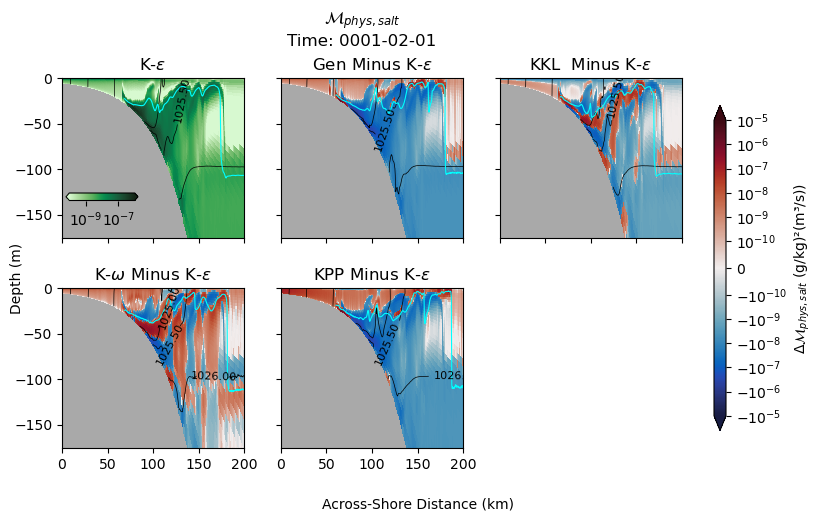

In [ ]:
# Plot Salt physical mixing 

# Make the figure 
fig, ax = plt.subplots(2, 3, figsize=(8,5))

# Set limits to focus on the jet
for r in range(3):
    for j in range(2):
        # Set the limits
        ax[j,r].set_xlim(0,200)
        ax[j,r].set_ylim(-175,0)
        ax[j,r].set_facecolor('darkgray')
        ax[j,r].set_aspect(1.0) # don't think this makes sense here since depth is m and across-shore is km

        # Plot mixed layer depth (when we have it) 



# Plot the salinity physical mixing for k-epsilon
p1 = ax[0,0].pcolormesh(y_rho/1000, ds_const_u3c4_keps.z_rho[time_idx_1mon,:,:,x_tran1], 
                        mphys_tran1_1mon_const_u3c4_keps[:,:],
                        cmap=cmap_mix_phy, norm=norm_mix_phy)
# Plot density contours
y_2d_c1 = np.tile(y_rho, (ds_const_u3c4_keps.z_rho[time_idx_1mon,:,:,x_tran1].shape[0], 1))
c1 = ax[0,0].contour(y_2d_c1/1000, ds_const_u3c4_keps.z_rho[time_idx1,:,:,x_tran1], rho_const_u3c4_keps[time_idx1,:,:,x_tran1],
        levels=lev_dens, colors='black', linewidths=0.5)
ax[0,0].clabel(c1, c1.levels, inline=True, fmt='%1.2f', fontsize=8)
# Add colorbar
cbar_ax1 = fig.add_axes([0.13,0.62,0.09,0.015])
fig.colorbar(p1,ax=ax,extend='both', ticks=[1e-9, 1e-7],
             pad=0.03, orientation='horizontal', cax=cbar_ax1)
# Plot mixed layer depth
c1b = ax[0,0].plot(y_rho/1000,  mld_const_u3c4_keps*(-1),
                      color='aqua', linewidth=0.8)

# Plot the difference in salt physical mixing between this and other runs 
# Gen
p2 = ax[0,1].pcolormesh(y_rho/1000, ds_const_u3c4_gen.z_rho[time_idx_1mon,:,:,x_tran1], 
                        (mphys_tran1_1mon_const_u3c4_gen-mphys_tran1_1mon_const_u3c4_keps),
                        cmap=cmap_mix_diff, norm=norm_mix_phy_diff)
# Plot density contours
y_2d_c2 = np.tile(y_rho, (ds_const_u3c4_gen.z_rho[time_idx_1mon,:,:,x_tran1].shape[0], 1))
c2 = ax[0,1].contour(y_2d_c2/1000, ds_const_u3c4_gen.z_rho[time_idx1,:,:,x_tran1], rho_const_u3c4_gen[time_idx1,:,:,x_tran1],
        levels=lev_dens, colors='black', linewidths=0.5)
ax[0,1].clabel(c2, c2.levels, inline=True, fmt='%1.2f', fontsize=8)
# Plot mixed layer depth
c2b = ax[0,1].plot(y_rho/1000,  mld_const_u3c4_gen*(-1),
                      color='aqua', linewidth=0.8)

# kkl
p3 = ax[0,2].pcolormesh(y_rho/1000, ds_const_u3c4_gen.z_rho[time_idx_1mon,:,:,x_tran1], 
                        (mphys_tran1_1mon_const_u3c4_kkl-mphys_tran1_1mon_const_u3c4_keps),
                        cmap=cmap_mix_diff, norm=norm_mix_phy_diff)
# Plot density contours
y_2d_c3 = np.tile(y_rho, (ds_const_u3c4_kkl.z_rho[time_idx_1mon,:,:,x_tran1].shape[0], 1))
c3 = ax[0,2].contour(y_2d_c3/1000, ds_const_u3c4_kkl.z_rho[time_idx1,:,:,x_tran1], rho_const_u3c4_kkl[time_idx1,:,:,x_tran1],
        levels=lev_dens, colors='black', linewidths=0.5)
ax[0,2].clabel(c3, c3.levels, inline=True, fmt='%1.2f', fontsize=8)
# Plot mixed layer depth
c3b = ax[0,2].plot(y_rho/1000,  mld_const_u3c4_kkl*(-1),
                      color='aqua', linewidth=0.8)

# K-omega
p4 = ax[1,0].pcolormesh(y_rho/1000, ds_const_u3c4_gen.z_rho[time_idx_1mon,:,:,x_tran1], 
                        (mphys_tran1_1mon_const_u3c4_komega-mphys_tran1_1mon_const_u3c4_keps),
                        cmap=cmap_mix_diff, norm=norm_mix_phy_diff)
# Plot density contours
y_2d_c4 = np.tile(y_rho, (ds_const_u3c4_komega.z_rho[time_idx_1mon,:,:,x_tran1].shape[0], 1))
c4 = ax[1,0].contour(y_2d_c4/1000, ds_const_u3c4_komega.z_rho[time_idx1,:,:,x_tran1], rho_const_u3c4_komega[time_idx1,:,:,x_tran1],
        levels=lev_dens, colors='black', linewidths=0.5)
ax[1,0].clabel(c4, c4.levels, inline=True, fmt='%1.2f', fontsize=8)
# Plot mixed layer depth
c4b = ax[1,0].plot(y_rho/1000,  mld_const_u3c4_komega*(-1),
                      color='aqua', linewidth=0.8)

# kpp
p5 = ax[1,1].pcolormesh(y_rho/1000, ds_const_u3c4_gen.z_rho[time_idx_1mon,:,:,x_tran1], 
                        (mphys_tran1_1mon_const_u3c4_kpp-mphys_tran1_1mon_const_u3c4_keps),
                        cmap=cmap_mix_diff, norm=norm_mix_phy_diff)
# Plot density contours
y_2d_c5 = np.tile(y_rho, (ds_const_u3c4_kpp.z_rho[time_idx_1mon,:,:,x_tran1].shape[0], 1))
c5 = ax[1,1].contour(y_2d_c5/1000, ds_const_u3c4_kpp.z_rho[time_idx1,:,:,x_tran1], rho_const_u3c4_kpp[time_idx1,:,:,x_tran1],
        levels=lev_dens, colors='black', linewidths=0.5)
ax[1,1].clabel(c5, c5.levels, inline=True, fmt='%1.2f', fontsize=8)
# Plot mixed layer depth
c5b = ax[1,1].plot(y_rho/1000,  mld_const_u3c4_kpp*(-1),
                      color='aqua', linewidth=0.8)


# Add colorbar fir difference plots
cbar_ax2 = fig.add_axes([0.94,0.16,0.015,0.65])
fig.colorbar(p2,ax=ax,extend='both', 
             pad=0.03, orientation='vertical', cax=cbar_ax2).set_label('$\Delta\mathcal{M}_{phys,salt}$ (g/kg)\u00b2(m\u00b3/s))')


# Label the plots/axes
ax[0,0].set_title('K-$\epsilon$') #, weight='bold')
ax[0,1].set_title('Gen Minus K-$\epsilon$') #, weight='bold')
ax[0,2].set_title('KKL  Minus K-$\epsilon$') #, weight='bold')
ax[1,0].set_title('K-$\omega$ Minus K-$\epsilon$') #, weight='bold')
ax[1,1].set_title('KPP Minus K-$\epsilon$') #, weight='bold')
# ax[0,3].set_title('$M_{phys,temp}$') #, weight='bold')
# ax[1,3].set_title('$M_{num,temp}$') #, weight='bold')

fig.suptitle('$\mathcal{M}_{phys,salt}$ \nTime: ' + str(ds_const_u3c4_keps.ocean_time[time_idx_1mon].values)[:10], y=1.001)
fig.text(0.45, 0.003, 'Across-Shore Distance (km)')
fig.text(0.06, 0.4, 'Depth (m)', rotation=90)

# Set the spacing
#plt.subplots_adjust(hspace=0.35)

# Remove the very last subplot
fig.delaxes(ax[1,2])

# Hide some axis labels 
plt.setp(ax[0,1].get_xticklabels(), visible=False)
plt.setp(ax[0,1].get_yticklabels(), visible=False)
plt.setp(ax[0,2].get_xticklabels(), visible=False)
plt.setp(ax[0,2].get_yticklabels(), visible=False)
# plt.setp(ax[0,3].get_xticklabels(), visible=False)
# plt.setp(ax[0,3].get_yticklabels(), visible=False)
plt.setp(ax[0,0].get_xticklabels(), visible=False)
plt.setp(ax[1,1].get_yticklabels(), visible=False)
plt.setp(ax[1,2].get_yticklabels(), visible=False)
# plt.setp(ax[1,3].get_yticklabels(), visible=False)

[None, None, None, None, None]

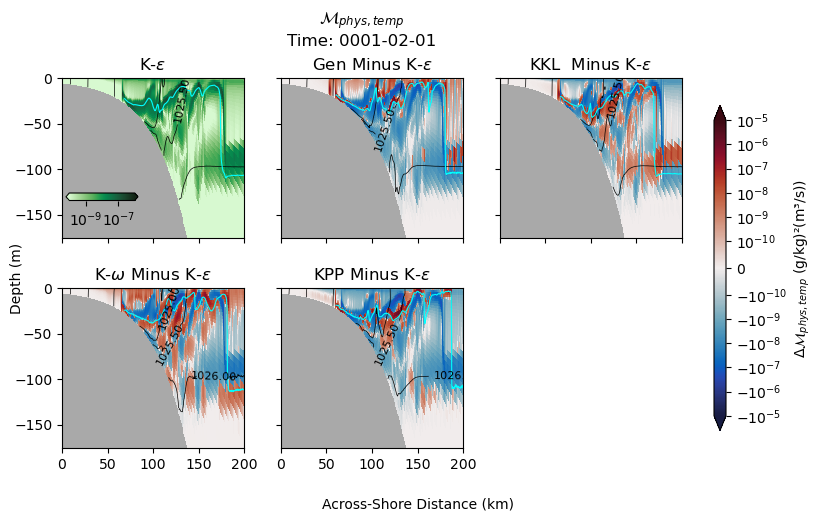

In [44]:
# Do this again for physical mixing of temperature 
# Make the figure 
fig, ax = plt.subplots(2, 3, figsize=(8,5))

# Set limits to focus on the jet
for r in range(3):
    for j in range(2):
        # Set the limits
        ax[j,r].set_xlim(0,200)
        ax[j,r].set_ylim(-175,0)
        ax[j,r].set_facecolor('darkgray')
        ax[j,r].set_aspect(1.0) # don't think this makes sense here since depth is m and across-shore is km

        # Plot mixed layer depth (when we have it) 



# Plot the temperature physical mixing for k-epsilon
p1 = ax[0,0].pcolormesh(y_rho/1000, ds_const_u3c4_keps.z_rho[time_idx_1mon,:,:,x_tran1], 
                        mphyt_tran1_1mon_const_u3c4_keps[:,:],
                        cmap=cmap_mix_phy, norm=norm_mix_phy)
# Plot density contours
y_2d_c1 = np.tile(y_rho, (ds_const_u3c4_keps.z_rho[time_idx_1mon,:,:,x_tran1].shape[0], 1))
c1 = ax[0,0].contour(y_2d_c1/1000, ds_const_u3c4_keps.z_rho[time_idx1,:,:,x_tran1], rho_const_u3c4_keps[time_idx1,:,:,x_tran1],
        levels=lev_dens, colors='black', linewidths=0.5)
ax[0,0].clabel(c1, c1.levels, inline=True, fmt='%1.2f', fontsize=8)
# Add colorbar
cbar_ax1 = fig.add_axes([0.13,0.62,0.09,0.015])
fig.colorbar(p1,ax=ax,extend='both', ticks=[1e-9, 1e-7],
             pad=0.03, orientation='horizontal', cax=cbar_ax1)
# Plot mixed layer depth
c1b = ax[0,0].plot(y_rho/1000,  mld_const_u3c4_keps*(-1),
                      color='aqua', linewidth=0.8)

# Plot the difference in salt physical mixing between this and other runs 
# Gen
p2 = ax[0,1].pcolormesh(y_rho/1000, ds_const_u3c4_gen.z_rho[time_idx_1mon,:,:,x_tran1], 
                        (mphyt_tran1_1mon_const_u3c4_gen-mphyt_tran1_1mon_const_u3c4_keps),
                        cmap=cmap_mix_diff, norm=norm_mix_phy_diff)
# Plot density contours
y_2d_c2 = np.tile(y_rho, (ds_const_u3c4_gen.z_rho[time_idx_1mon,:,:,x_tran1].shape[0], 1))
c2 = ax[0,1].contour(y_2d_c2/1000, ds_const_u3c4_gen.z_rho[time_idx1,:,:,x_tran1], rho_const_u3c4_gen[time_idx1,:,:,x_tran1],
        levels=lev_dens, colors='black', linewidths=0.5)
ax[0,1].clabel(c2, c2.levels, inline=True, fmt='%1.2f', fontsize=8)
# Plot mixed layer depth
c2b = ax[0,1].plot(y_rho/1000,  mld_const_u3c4_gen*(-1),
                      color='aqua', linewidth=0.8)

# kkl
p3 = ax[0,2].pcolormesh(y_rho/1000, ds_const_u3c4_gen.z_rho[time_idx_1mon,:,:,x_tran1], 
                        (mphyt_tran1_1mon_const_u3c4_kkl-mphyt_tran1_1mon_const_u3c4_keps),
                        cmap=cmap_mix_diff, norm=norm_mix_phy_diff)
# Plot density contours
y_2d_c3 = np.tile(y_rho, (ds_const_u3c4_kkl.z_rho[time_idx_1mon,:,:,x_tran1].shape[0], 1))
c3 = ax[0,2].contour(y_2d_c3/1000, ds_const_u3c4_kkl.z_rho[time_idx1,:,:,x_tran1], rho_const_u3c4_kkl[time_idx1,:,:,x_tran1],
        levels=lev_dens, colors='black', linewidths=0.5)
ax[0,2].clabel(c3, c3.levels, inline=True, fmt='%1.2f', fontsize=8)
# Plot mixed layer depth
c3b = ax[0,2].plot(y_rho/1000,  mld_const_u3c4_kkl*(-1),
                      color='aqua', linewidth=0.8)

# K-omega
p4 = ax[1,0].pcolormesh(y_rho/1000, ds_const_u3c4_gen.z_rho[time_idx_1mon,:,:,x_tran1], 
                        (mphyt_tran1_1mon_const_u3c4_komega-mphyt_tran1_1mon_const_u3c4_keps),
                        cmap=cmap_mix_diff, norm=norm_mix_phy_diff)
# Plot density contours
y_2d_c4 = np.tile(y_rho, (ds_const_u3c4_komega.z_rho[time_idx_1mon,:,:,x_tran1].shape[0], 1))
c4 = ax[1,0].contour(y_2d_c4/1000, ds_const_u3c4_komega.z_rho[time_idx1,:,:,x_tran1], rho_const_u3c4_komega[time_idx1,:,:,x_tran1],
        levels=lev_dens, colors='black', linewidths=0.5)
ax[1,0].clabel(c4, c4.levels, inline=True, fmt='%1.2f', fontsize=8)
# Plot mixed layer depth
c4b = ax[1,0].plot(y_rho/1000,  mld_const_u3c4_komega*(-1),
                      color='aqua', linewidth=0.8)

# kpp
p5 = ax[1,1].pcolormesh(y_rho/1000, ds_const_u3c4_gen.z_rho[time_idx_1mon,:,:,x_tran1], 
                        (mphyt_tran1_1mon_const_u3c4_kpp-mphyt_tran1_1mon_const_u3c4_keps),
                        cmap=cmap_mix_diff, norm=norm_mix_phy_diff)
# Plot density contours
y_2d_c5 = np.tile(y_rho, (ds_const_u3c4_kpp.z_rho[time_idx_1mon,:,:,x_tran1].shape[0], 1))
c5 = ax[1,1].contour(y_2d_c5/1000, ds_const_u3c4_kpp.z_rho[time_idx1,:,:,x_tran1], rho_const_u3c4_kpp[time_idx1,:,:,x_tran1],
        levels=lev_dens, colors='black', linewidths=0.5)
ax[1,1].clabel(c5, c5.levels, inline=True, fmt='%1.2f', fontsize=8)
# Plot mixed layer depth
c5b = ax[1,1].plot(y_rho/1000,  mld_const_u3c4_kpp*(-1),
                      color='aqua', linewidth=0.8)


# Add colorbar fir difference plots
cbar_ax2 = fig.add_axes([0.94,0.16,0.015,0.65])
fig.colorbar(p2,ax=ax,extend='both', 
             pad=0.03, orientation='vertical', cax=cbar_ax2).set_label('$\Delta\mathcal{M}_{phys,temp}$ (g/kg)\u00b2(m\u00b3/s))')


# Label the plots/axes
ax[0,0].set_title('K-$\epsilon$') #, weight='bold')
ax[0,1].set_title('Gen Minus K-$\epsilon$') #, weight='bold')
ax[0,2].set_title('KKL  Minus K-$\epsilon$') #, weight='bold')
ax[1,0].set_title('K-$\omega$ Minus K-$\epsilon$') #, weight='bold')
ax[1,1].set_title('KPP Minus K-$\epsilon$') #, weight='bold')
# ax[0,3].set_title('$M_{phys,temp}$') #, weight='bold')
# ax[1,3].set_title('$M_{num,temp}$') #, weight='bold')

fig.suptitle('$\mathcal{M}_{phys,temp}$ \nTime: ' + str(ds_const_u3c4_keps.ocean_time[time_idx_1mon].values)[:10], y=1.001)
fig.text(0.45, 0.003, 'Across-Shore Distance (km)')
fig.text(0.06, 0.4, 'Depth (m)', rotation=90)

# Set the spacing
#plt.subplots_adjust(hspace=0.35)

# Remove the very last subplot
fig.delaxes(ax[1,2])

# Hide some axis labels 
plt.setp(ax[0,1].get_xticklabels(), visible=False)
plt.setp(ax[0,1].get_yticklabels(), visible=False)
plt.setp(ax[0,2].get_xticklabels(), visible=False)
plt.setp(ax[0,2].get_yticklabels(), visible=False)
# plt.setp(ax[0,3].get_xticklabels(), visible=False)
# plt.setp(ax[0,3].get_yticklabels(), visible=False)
plt.setp(ax[0,0].get_xticklabels(), visible=False)
plt.setp(ax[1,1].get_yticklabels(), visible=False)
plt.setp(ax[1,2].get_yticklabels(), visible=False)
# plt.setp(ax[1,3].get_yticklabels(), visible=False)

[None, None, None, None, None]

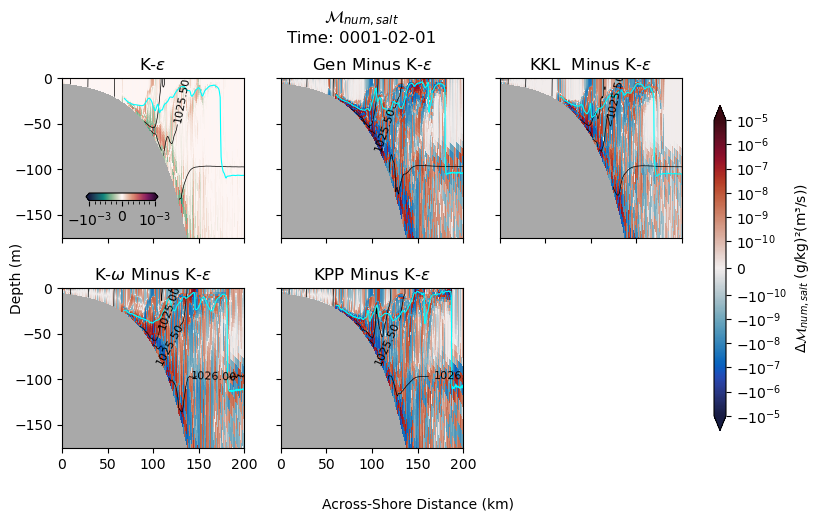

In [46]:
# And now for numerical mixing of salt

# Make the figure 
fig, ax = plt.subplots(2, 3, figsize=(8,5))

# Set limits to focus on the jet
for r in range(3):
    for j in range(2):
        # Set the limits
        ax[j,r].set_xlim(0,200)
        ax[j,r].set_ylim(-175,0)
        ax[j,r].set_facecolor('darkgray')
        ax[j,r].set_aspect(1.0) # don't think this makes sense here since depth is m and across-shore is km

        # Plot mixed layer depth (when we have it) 



# Plot the temperature physical mixing for k-epsilon
p1 = ax[0,0].pcolormesh(y_rho/1000, ds_const_u3c4_keps.z_rho[time_idx_1mon,:,:,x_tran1], 
                        mnum_salt_dv_tran1_1mon_const_u3c4_keps[:,:],
                        cmap=cmap_mix_num, norm=norm_mix_num)
# Plot density contours
y_2d_c1 = np.tile(y_rho, (ds_const_u3c4_keps.z_rho[time_idx_1mon,:,:,x_tran1].shape[0], 1))
c1 = ax[0,0].contour(y_2d_c1/1000, ds_const_u3c4_keps.z_rho[time_idx1,:,:,x_tran1], rho_const_u3c4_keps[time_idx1,:,:,x_tran1],
        levels=lev_dens, colors='black', linewidths=0.5)
ax[0,0].clabel(c1, c1.levels, inline=True, fmt='%1.2f', fontsize=8)
# Add colorbar
cbar_ax1 = fig.add_axes([0.155,0.62,0.09,0.015])
fig.colorbar(p1,ax=ax,extend='both', ticks=[-1e-3, 0, 1e-3],
             pad=0.03, orientation='horizontal', cax=cbar_ax1)
# Plot mixed layer depth
c1b = ax[0,0].plot(y_rho/1000,  mld_const_u3c4_keps*(-1),
                      color='aqua', linewidth=0.8)

# Plot the difference in salt physical mixing between this and other runs 
# Gen
p2 = ax[0,1].pcolormesh(y_rho/1000, ds_const_u3c4_gen.z_rho[time_idx_1mon,:,:,x_tran1], 
                        (mnum_salt_dv_tran1_1mon_const_u3c4_gen-mnum_salt_dv_tran1_1mon_const_u3c4_keps),
                        cmap=cmap_mix_diff, norm=norm_mix_phy_diff)
# Plot density contours
y_2d_c2 = np.tile(y_rho, (ds_const_u3c4_gen.z_rho[time_idx_1mon,:,:,x_tran1].shape[0], 1))
c2 = ax[0,1].contour(y_2d_c2/1000, ds_const_u3c4_gen.z_rho[time_idx1,:,:,x_tran1], rho_const_u3c4_gen[time_idx1,:,:,x_tran1],
        levels=lev_dens, colors='black', linewidths=0.5)
ax[0,1].clabel(c2, c2.levels, inline=True, fmt='%1.2f', fontsize=8)
# Plot mixed layer depth
c2b = ax[0,1].plot(y_rho/1000,  mld_const_u3c4_gen*(-1),
                      color='aqua', linewidth=0.8)

# kkl
p3 = ax[0,2].pcolormesh(y_rho/1000, ds_const_u3c4_gen.z_rho[time_idx_1mon,:,:,x_tran1], 
                        (mnum_salt_dv_tran1_1mon_const_u3c4_kkl-mnum_salt_dv_tran1_1mon_const_u3c4_keps),
                        cmap=cmap_mix_diff, norm=norm_mix_phy_diff)
# Plot density contours
y_2d_c3 = np.tile(y_rho, (ds_const_u3c4_kkl.z_rho[time_idx_1mon,:,:,x_tran1].shape[0], 1))
c3 = ax[0,2].contour(y_2d_c3/1000, ds_const_u3c4_kkl.z_rho[time_idx1,:,:,x_tran1], rho_const_u3c4_kkl[time_idx1,:,:,x_tran1],
        levels=lev_dens, colors='black', linewidths=0.5)
ax[0,2].clabel(c3, c3.levels, inline=True, fmt='%1.2f', fontsize=8)
# Plot mixed layer depth
c3b = ax[0,2].plot(y_rho/1000,  mld_const_u3c4_kkl*(-1),
                      color='aqua', linewidth=0.8)

# K-omega
p4 = ax[1,0].pcolormesh(y_rho/1000, ds_const_u3c4_gen.z_rho[time_idx_1mon,:,:,x_tran1], 
                        (mnum_salt_dv_tran1_1mon_const_u3c4_komega-mnum_salt_dv_tran1_1mon_const_u3c4_keps),
                        cmap=cmap_mix_diff, norm=norm_mix_phy_diff)
# Plot density contours
y_2d_c4 = np.tile(y_rho, (ds_const_u3c4_komega.z_rho[time_idx_1mon,:,:,x_tran1].shape[0], 1))
c4 = ax[1,0].contour(y_2d_c4/1000, ds_const_u3c4_komega.z_rho[time_idx1,:,:,x_tran1], rho_const_u3c4_komega[time_idx1,:,:,x_tran1],
        levels=lev_dens, colors='black', linewidths=0.5)
ax[1,0].clabel(c4, c4.levels, inline=True, fmt='%1.2f', fontsize=8)
# Plot mixed layer depth
c4b = ax[1,0].plot(y_rho/1000,  mld_const_u3c4_komega*(-1),
                      color='aqua', linewidth=0.8)

# kpp
p5 = ax[1,1].pcolormesh(y_rho/1000, ds_const_u3c4_gen.z_rho[time_idx_1mon,:,:,x_tran1], 
                        (mnum_salt_dv_tran1_1mon_const_u3c4_kpp-mnum_salt_dv_tran1_1mon_const_u3c4_keps),
                        cmap=cmap_mix_diff, norm=norm_mix_phy_diff)
# Plot density contours
y_2d_c5 = np.tile(y_rho, (ds_const_u3c4_kpp.z_rho[time_idx_1mon,:,:,x_tran1].shape[0], 1))
c5 = ax[1,1].contour(y_2d_c5/1000, ds_const_u3c4_kpp.z_rho[time_idx1,:,:,x_tran1], rho_const_u3c4_kpp[time_idx1,:,:,x_tran1],
        levels=lev_dens, colors='black', linewidths=0.5)
ax[1,1].clabel(c5, c5.levels, inline=True, fmt='%1.2f', fontsize=8)
# Plot mixed layer depth
c5b = ax[1,1].plot(y_rho/1000,  mld_const_u3c4_kpp*(-1),
                      color='aqua', linewidth=0.8)


# Add colorbar fir difference plots
cbar_ax2 = fig.add_axes([0.94,0.16,0.015,0.65])
fig.colorbar(p2,ax=ax,extend='both', 
             pad=0.03, orientation='vertical', cax=cbar_ax2).set_label('$\Delta\mathcal{M}_{num,salt}$ (g/kg)\u00b2(m\u00b3/s))')


# Label the plots/axes
ax[0,0].set_title('K-$\epsilon$') #, weight='bold')
ax[0,1].set_title('Gen Minus K-$\epsilon$') #, weight='bold')
ax[0,2].set_title('KKL  Minus K-$\epsilon$') #, weight='bold')
ax[1,0].set_title('K-$\omega$ Minus K-$\epsilon$') #, weight='bold')
ax[1,1].set_title('KPP Minus K-$\epsilon$') #, weight='bold')
# ax[0,3].set_title('$M_{phys,temp}$') #, weight='bold')
# ax[1,3].set_title('$M_{num,temp}$') #, weight='bold')

fig.suptitle('$\mathcal{M}_{num,salt}$ \nTime: ' + str(ds_const_u3c4_keps.ocean_time[time_idx_1mon].values)[:10], y=1.001)
fig.text(0.45, 0.003, 'Across-Shore Distance (km)')
fig.text(0.06, 0.4, 'Depth (m)', rotation=90)

# Set the spacing
#plt.subplots_adjust(hspace=0.35)

# Remove the very last subplot
fig.delaxes(ax[1,2])

# Hide some axis labels 
plt.setp(ax[0,1].get_xticklabels(), visible=False)
plt.setp(ax[0,1].get_yticklabels(), visible=False)
plt.setp(ax[0,2].get_xticklabels(), visible=False)
plt.setp(ax[0,2].get_yticklabels(), visible=False)
# plt.setp(ax[0,3].get_xticklabels(), visible=False)
# plt.setp(ax[0,3].get_yticklabels(), visible=False)
plt.setp(ax[0,0].get_xticklabels(), visible=False)
plt.setp(ax[1,1].get_yticklabels(), visible=False)
plt.setp(ax[1,2].get_yticklabels(), visible=False)
# plt.setp(ax[1,3].get_yticklabels(), visible=False)

[None, None, None, None, None]

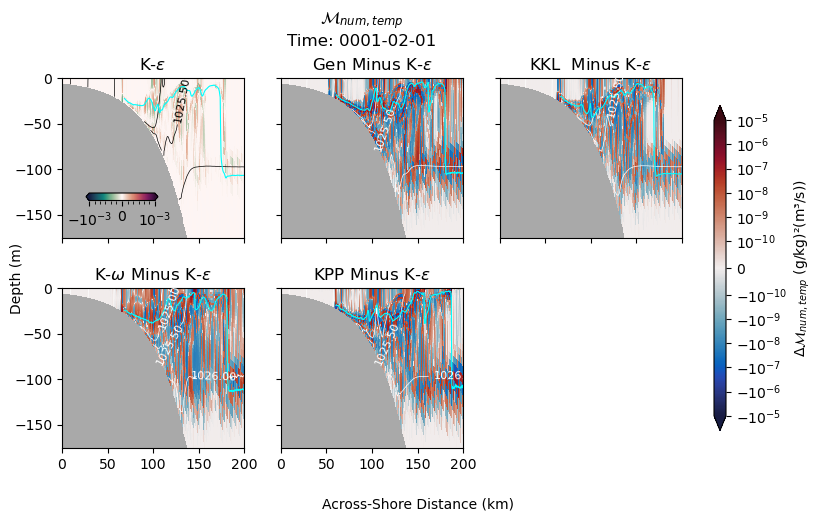

In [47]:
# And numerical mixing of temperature 
# Make the figure 
fig, ax = plt.subplots(2, 3, figsize=(8,5))

# Set limits to focus on the jet
for r in range(3):
    for j in range(2):
        # Set the limits
        ax[j,r].set_xlim(0,200)
        ax[j,r].set_ylim(-175,0)
        ax[j,r].set_facecolor('darkgray')
        ax[j,r].set_aspect(1.0) # don't think this makes sense here since depth is m and across-shore is km

        # Plot mixed layer depth (when we have it) 



# Plot the temperature physical mixing for k-epsilon
p1 = ax[0,0].pcolormesh(y_rho/1000, ds_const_u3c4_keps.z_rho[time_idx_1mon,:,:,x_tran1], 
                        mnum_temp_dv_tran1_1mon_const_u3c4_keps[:,:],
                        cmap=cmap_mix_num, norm=norm_mix_num)
# Plot density contours
y_2d_c1 = np.tile(y_rho, (ds_const_u3c4_keps.z_rho[time_idx_1mon,:,:,x_tran1].shape[0], 1))
c1 = ax[0,0].contour(y_2d_c1/1000, ds_const_u3c4_keps.z_rho[time_idx1,:,:,x_tran1], rho_const_u3c4_keps[time_idx1,:,:,x_tran1],
        levels=lev_dens, colors='black', linewidths=0.5)
ax[0,0].clabel(c1, c1.levels, inline=True, fmt='%1.2f', fontsize=8)
# Add colorbar
cbar_ax1 = fig.add_axes([0.155,0.62,0.09,0.015])
fig.colorbar(p1,ax=ax,extend='both', ticks=[-1e-3, 0, 1e-3],
             pad=0.03, orientation='horizontal', cax=cbar_ax1)
# Plot mixed layer depth
c1b = ax[0,0].plot(y_rho/1000,  mld_const_u3c4_keps*(-1),
                      color='aqua', linewidth=0.8)

# Plot the difference in salt physical mixing between this and other runs 
# Gen
p2 = ax[0,1].pcolormesh(y_rho/1000, ds_const_u3c4_gen.z_rho[time_idx_1mon,:,:,x_tran1], 
                        (mnum_temp_dv_tran1_1mon_const_u3c4_gen-mnum_temp_dv_tran1_1mon_const_u3c4_keps),
                        cmap=cmap_mix_diff, norm=norm_mix_phy_diff)
# Plot density contours
y_2d_c2 = np.tile(y_rho, (ds_const_u3c4_gen.z_rho[time_idx_1mon,:,:,x_tran1].shape[0], 1))
c2 = ax[0,1].contour(y_2d_c2/1000, ds_const_u3c4_gen.z_rho[time_idx1,:,:,x_tran1], rho_const_u3c4_gen[time_idx1,:,:,x_tran1],
        levels=lev_dens, colors='white', linewidths=0.5)
ax[0,1].clabel(c2, c2.levels, inline=True, fmt='%1.2f', fontsize=8)
# Plot mixed layer depth
c2b = ax[0,1].plot(y_rho/1000,  mld_const_u3c4_gen*(-1),
                      color='aqua', linewidth=0.8)

# kkl
p3 = ax[0,2].pcolormesh(y_rho/1000, ds_const_u3c4_gen.z_rho[time_idx_1mon,:,:,x_tran1], 
                        (mnum_temp_dv_tran1_1mon_const_u3c4_kkl-mnum_temp_dv_tran1_1mon_const_u3c4_keps),
                        cmap=cmap_mix_diff, norm=norm_mix_phy_diff)
# Plot density contours
y_2d_c3 = np.tile(y_rho, (ds_const_u3c4_kkl.z_rho[time_idx_1mon,:,:,x_tran1].shape[0], 1))
c3 = ax[0,2].contour(y_2d_c3/1000, ds_const_u3c4_kkl.z_rho[time_idx1,:,:,x_tran1], rho_const_u3c4_kkl[time_idx1,:,:,x_tran1],
        levels=lev_dens, colors='white', linewidths=0.5)
ax[0,2].clabel(c3, c3.levels, inline=True, fmt='%1.2f', fontsize=8)
# Plot mixed layer depth
c3b = ax[0,2].plot(y_rho/1000,  mld_const_u3c4_kkl*(-1),
                      color='aqua', linewidth=0.8)

# K-omega
p4 = ax[1,0].pcolormesh(y_rho/1000, ds_const_u3c4_gen.z_rho[time_idx_1mon,:,:,x_tran1], 
                        (mnum_temp_dv_tran1_1mon_const_u3c4_komega-mnum_temp_dv_tran1_1mon_const_u3c4_keps),
                        cmap=cmap_mix_diff, norm=norm_mix_phy_diff)
# Plot density contours
y_2d_c4 = np.tile(y_rho, (ds_const_u3c4_komega.z_rho[time_idx_1mon,:,:,x_tran1].shape[0], 1))
c4 = ax[1,0].contour(y_2d_c4/1000, ds_const_u3c4_komega.z_rho[time_idx1,:,:,x_tran1], rho_const_u3c4_komega[time_idx1,:,:,x_tran1],
        levels=lev_dens, colors='white', linewidths=0.5)
ax[1,0].clabel(c4, c4.levels, inline=True, fmt='%1.2f', fontsize=8)
# Plot mixed layer depth
c4b = ax[1,0].plot(y_rho/1000,  mld_const_u3c4_komega*(-1),
                      color='aqua', linewidth=0.8)

# kpp
p5 = ax[1,1].pcolormesh(y_rho/1000, ds_const_u3c4_gen.z_rho[time_idx_1mon,:,:,x_tran1], 
                        (mnum_temp_dv_tran1_1mon_const_u3c4_kpp-mnum_temp_dv_tran1_1mon_const_u3c4_keps),
                        cmap=cmap_mix_diff, norm=norm_mix_phy_diff)
# Plot density contours
y_2d_c5 = np.tile(y_rho, (ds_const_u3c4_kpp.z_rho[time_idx_1mon,:,:,x_tran1].shape[0], 1))
c5 = ax[1,1].contour(y_2d_c5/1000, ds_const_u3c4_kpp.z_rho[time_idx1,:,:,x_tran1], rho_const_u3c4_kpp[time_idx1,:,:,x_tran1],
        levels=lev_dens, colors='white', linewidths=0.5)
ax[1,1].clabel(c5, c5.levels, inline=True, fmt='%1.2f', fontsize=8)
# Plot mixed layer depth
c5b = ax[1,1].plot(y_rho/1000,  mld_const_u3c4_kpp*(-1),
                      color='aqua', linewidth=0.8)


# Add colorbar fir difference plots
cbar_ax2 = fig.add_axes([0.94,0.16,0.015,0.65])
fig.colorbar(p2,ax=ax,extend='both', 
             pad=0.03, orientation='vertical', cax=cbar_ax2).set_label('$\Delta\mathcal{M}_{num,temp}$ (g/kg)\u00b2(m\u00b3/s))')


# Label the plots/axes
ax[0,0].set_title('K-$\epsilon$') #, weight='bold')
ax[0,1].set_title('Gen Minus K-$\epsilon$') #, weight='bold')
ax[0,2].set_title('KKL  Minus K-$\epsilon$') #, weight='bold')
ax[1,0].set_title('K-$\omega$ Minus K-$\epsilon$') #, weight='bold')
ax[1,1].set_title('KPP Minus K-$\epsilon$') #, weight='bold')
# ax[0,3].set_title('$M_{phys,temp}$') #, weight='bold')
# ax[1,3].set_title('$M_{num,temp}$') #, weight='bold')

fig.suptitle('$\mathcal{M}_{num,temp}$ \nTime: ' + str(ds_const_u3c4_keps.ocean_time[time_idx_1mon].values)[:10], y=1.001)
fig.text(0.45, 0.003, 'Across-Shore Distance (km)')
fig.text(0.06, 0.4, 'Depth (m)', rotation=90)

# Set the spacing
#plt.subplots_adjust(hspace=0.35)

# Remove the very last subplot
fig.delaxes(ax[1,2])

# Hide some axis labels 
plt.setp(ax[0,1].get_xticklabels(), visible=False)
plt.setp(ax[0,1].get_yticklabels(), visible=False)
plt.setp(ax[0,2].get_xticklabels(), visible=False)
plt.setp(ax[0,2].get_yticklabels(), visible=False)
# plt.setp(ax[0,3].get_xticklabels(), visible=False)
# plt.setp(ax[0,3].get_yticklabels(), visible=False)
plt.setp(ax[0,0].get_xticklabels(), visible=False)
plt.setp(ax[1,1].get_yticklabels(), visible=False)
plt.setp(ax[1,2].get_yticklabels(), visible=False)
# plt.setp(ax[1,3].get_yticklabels(), visible=False)

In [ ]:
(mnum_temp_dv_tran1_1mon_const_u3c4_gen-mnum_temp_dv_tran1_1mon_const_u3c4_keps)

## Salinity  
Make cross-sections comparing salinity for the different runs with absolutle plots for K-epsilon and different plots for the other vertical mixing schemes.

In [48]:
# Set the colormap
cmap_salt = cmo.haline
cmap_salt_diff = cmo.balance

# Set the levels
lev_salt = np.arange(30,32,0.1)
lev_salt_diff = np.arange(-1,1,0.01)

# Make the norm
norm_salt = BoundaryNorm(lev_salt, ncolors=cmap_salt.N, clip=True)
norm_salt_diff = BoundaryNorm(lev_salt_diff, ncolors=cmap_salt_diff.N, clip=True)



[None, None, None, None, None]

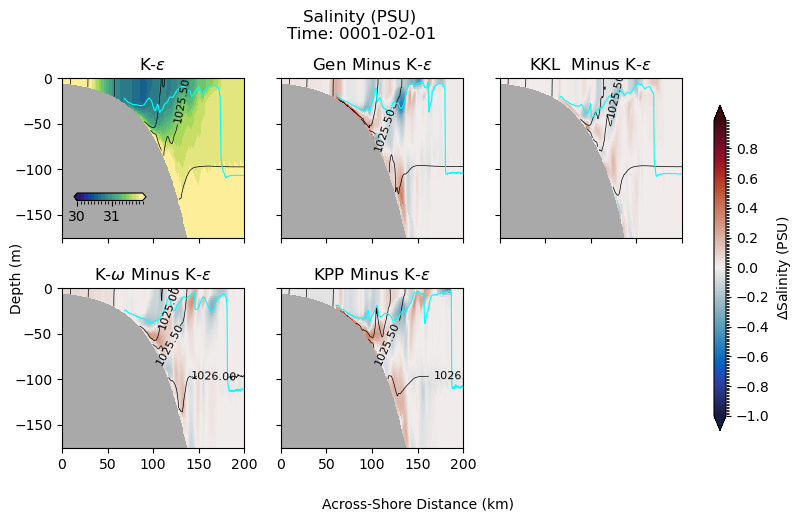

In [49]:
# Make the figure 
fig, ax = plt.subplots(2, 3, figsize=(8,5))

# Set limits to focus on the jet
for r in range(3):
    for j in range(2):
        # Set the limits
        ax[j,r].set_xlim(0,200)
        ax[j,r].set_ylim(-175,0)
        ax[j,r].set_facecolor('darkgray')
        ax[j,r].set_aspect(1.0) # don't think this makes sense here since depth is m and across-shore is km

        # Plot mixed layer depth (when we have it) 



# Plot the salinity physical mixing for k-epsilon
p1 = ax[0,0].pcolormesh(y_rho/1000, ds_const_u3c4_keps.z_rho[time_idx_1mon,:,:,x_tran1], 
                        ds_const_u3c4_keps.salt[time_idx_1mon,:,:,x_tran1],
                        cmap=cmap_salt, norm=norm_salt)
# Plot density contours
y_2d_c1 = np.tile(y_rho, (ds_const_u3c4_keps.z_rho[time_idx_1mon,:,:,x_tran1].shape[0], 1))
c1 = ax[0,0].contour(y_2d_c1/1000, ds_const_u3c4_keps.z_rho[time_idx1,:,:,x_tran1], rho_const_u3c4_keps[time_idx1,:,:,x_tran1],
        levels=lev_dens, colors='black', linewidths=0.5)
ax[0,0].clabel(c1, c1.levels, inline=True, fmt='%1.2f', fontsize=8)
# Add colorbar
cbar_ax1 = fig.add_axes([0.14,0.62,0.09,0.015])
fig.colorbar(p1,ax=ax,extend='both', ticks=[30,31,32],
             pad=0.03, orientation='horizontal', cax=cbar_ax1)
# Plot mixed layer depth
c1b = ax[0,0].plot(y_rho/1000,  mld_const_u3c4_keps*(-1),
                      color='aqua', linewidth=0.8)

# Plot the difference in salt physical mixing between this and other runs 
# Gen
p2 = ax[0,1].pcolormesh(y_rho/1000, ds_const_u3c4_gen.z_rho[time_idx_1mon,:,:,x_tran1], 
                        (ds_const_u3c4_gen.salt[time_idx_1mon,:,:,x_tran1]-ds_const_u3c4_keps.salt[time_idx_1mon,:,:,x_tran1]),
                        cmap=cmap_salt_diff, norm=norm_salt_diff)
# Plot density contours
y_2d_c2 = np.tile(y_rho, (ds_const_u3c4_gen.z_rho[time_idx_1mon,:,:,x_tran1].shape[0], 1))
c2 = ax[0,1].contour(y_2d_c2/1000, ds_const_u3c4_gen.z_rho[time_idx1,:,:,x_tran1], rho_const_u3c4_gen[time_idx1,:,:,x_tran1],
        levels=lev_dens, colors='black', linewidths=0.5)
ax[0,1].clabel(c2, c2.levels, inline=True, fmt='%1.2f', fontsize=8)
# Plot mixed layer depth
c2b = ax[0,1].plot(y_rho/1000,  mld_const_u3c4_gen*(-1),
                      color='aqua', linewidth=0.8)

# kkl
p3 = ax[0,2].pcolormesh(y_rho/1000, ds_const_u3c4_gen.z_rho[time_idx_1mon,:,:,x_tran1], 
                        (ds_const_u3c4_kkl.salt[time_idx_1mon,:,:,x_tran1]-ds_const_u3c4_keps.salt[time_idx_1mon,:,:,x_tran1]),
                        cmap=cmap_salt_diff, norm=norm_salt_diff)
# Plot density contours
y_2d_c3 = np.tile(y_rho, (ds_const_u3c4_kkl.z_rho[time_idx_1mon,:,:,x_tran1].shape[0], 1))
c3 = ax[0,2].contour(y_2d_c3/1000, ds_const_u3c4_kkl.z_rho[time_idx1,:,:,x_tran1], rho_const_u3c4_kkl[time_idx1,:,:,x_tran1],
        levels=lev_dens, colors='black', linewidths=0.5)
ax[0,2].clabel(c3, c3.levels, inline=True, fmt='%1.2f', fontsize=8)
# Plot mixed layer depth
c3b = ax[0,2].plot(y_rho/1000,  mld_const_u3c4_kkl*(-1),
                      color='aqua', linewidth=0.8)

# K-omega
p4 = ax[1,0].pcolormesh(y_rho/1000, ds_const_u3c4_gen.z_rho[time_idx_1mon,:,:,x_tran1], 
                        (ds_const_u3c4_komega.salt[time_idx_1mon,:,:,x_tran1]-ds_const_u3c4_keps.salt[time_idx_1mon,:,:,x_tran1]),
                        cmap=cmap_salt_diff, norm=norm_salt_diff)
# Plot density contours
y_2d_c4 = np.tile(y_rho, (ds_const_u3c4_komega.z_rho[time_idx_1mon,:,:,x_tran1].shape[0], 1))
c4 = ax[1,0].contour(y_2d_c4/1000, ds_const_u3c4_komega.z_rho[time_idx1,:,:,x_tran1], rho_const_u3c4_komega[time_idx1,:,:,x_tran1],
        levels=lev_dens, colors='black', linewidths=0.5)
ax[1,0].clabel(c4, c4.levels, inline=True, fmt='%1.2f', fontsize=8)
# Plot mixed layer depth
c4b = ax[1,0].plot(y_rho/1000,  mld_const_u3c4_komega*(-1),
                      color='aqua', linewidth=0.8)

# kpp
p5 = ax[1,1].pcolormesh(y_rho/1000, ds_const_u3c4_gen.z_rho[time_idx_1mon,:,:,x_tran1], 
                        (ds_const_u3c4_kpp.salt[time_idx_1mon,:,:,x_tran1]-ds_const_u3c4_keps.salt[time_idx_1mon,:,:,x_tran1]),
                        cmap=cmap_salt_diff, norm=norm_salt_diff)
# Plot density contours
y_2d_c5 = np.tile(y_rho, (ds_const_u3c4_kpp.z_rho[time_idx_1mon,:,:,x_tran1].shape[0], 1))
c5 = ax[1,1].contour(y_2d_c5/1000, ds_const_u3c4_kpp.z_rho[time_idx1,:,:,x_tran1], rho_const_u3c4_kpp[time_idx1,:,:,x_tran1],
        levels=lev_dens, colors='black', linewidths=0.5)
ax[1,1].clabel(c5, c5.levels, inline=True, fmt='%1.2f', fontsize=8)
# Plot mixed layer depth
c5b = ax[1,1].plot(y_rho/1000,  mld_const_u3c4_kpp*(-1),
                      color='aqua', linewidth=0.8)


# Add colorbar fir difference plots
cbar_ax2 = fig.add_axes([0.94,0.16,0.015,0.65])
fig.colorbar(p2,ax=ax,extend='both', 
             pad=0.03, orientation='vertical', cax=cbar_ax2).set_label('$\Delta$Salinity (PSU)')


# Label the plots/axes
ax[0,0].set_title('K-$\epsilon$') #, weight='bold')
ax[0,1].set_title('Gen Minus K-$\epsilon$') #, weight='bold')
ax[0,2].set_title('KKL  Minus K-$\epsilon$') #, weight='bold')
ax[1,0].set_title('K-$\omega$ Minus K-$\epsilon$') #, weight='bold')
ax[1,1].set_title('KPP Minus K-$\epsilon$') #, weight='bold')
# ax[0,3].set_title('$M_{phys,temp}$') #, weight='bold')
# ax[1,3].set_title('$M_{num,temp}$') #, weight='bold')

fig.suptitle('Salinity (PSU) \nTime: ' + str(ds_const_u3c4_keps.ocean_time[time_idx_1mon].values)[:10], y=1.001)
fig.text(0.45, 0.003, 'Across-Shore Distance (km)')
fig.text(0.06, 0.4, 'Depth (m)', rotation=90)

# Set the spacing
#plt.subplots_adjust(hspace=0.35)

# Remove the very last subplot
fig.delaxes(ax[1,2])

# Hide some axis labels 
plt.setp(ax[0,1].get_xticklabels(), visible=False)
plt.setp(ax[0,1].get_yticklabels(), visible=False)
plt.setp(ax[0,2].get_xticklabels(), visible=False)
plt.setp(ax[0,2].get_yticklabels(), visible=False)
# plt.setp(ax[0,3].get_xticklabels(), visible=False)
# plt.setp(ax[0,3].get_yticklabels(), visible=False)
plt.setp(ax[0,0].get_xticklabels(), visible=False)
plt.setp(ax[1,1].get_yticklabels(), visible=False)
plt.setp(ax[1,2].get_yticklabels(), visible=False)
# plt.setp(ax[1,3].get_yticklabels(), visible=False)

In [ ]:
# Plot salinity at one time for K-eps at transect 2
# (then add on difference plots)



## Temperature  
 Make the sam plots/analysis as above but for temperature

In [50]:
# Set the colormap
cmap_temp = cmo.thermal
cmap_temp_diff = cmo.balance

# Set the levels
lev_temp = np.arange(-2.5,-1.1,0.01)
lev_temp_diff = np.arange(-0.5,0.5,0.01)

# Make the norm
norm_temp = BoundaryNorm(lev_temp, ncolors=cmap_temp.N, clip=True)
norm_temp_diff = BoundaryNorm(lev_temp_diff, ncolors=cmap_temp_diff.N, clip=True)


[None, None, None, None, None]

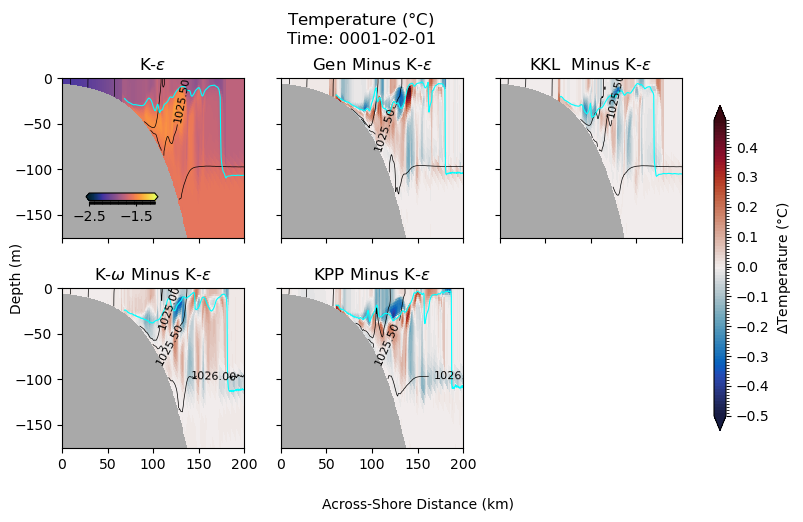

In [51]:
# Make the figure 
fig, ax = plt.subplots(2, 3, figsize=(8,5))

# Set limits to focus on the jet
for r in range(3):
    for j in range(2):
        # Set the limits
        ax[j,r].set_xlim(0,200)
        ax[j,r].set_ylim(-175,0)
        ax[j,r].set_facecolor('darkgray')
        ax[j,r].set_aspect(1.0) # don't think this makes sense here since depth is m and across-shore is km

        # Plot mixed layer depth (when we have it) 



# Plot the salinity physical mixing for k-epsilon
p1 = ax[0,0].pcolormesh(y_rho/1000, ds_const_u3c4_keps.z_rho[time_idx_1mon,:,:,x_tran1], 
                        ds_const_u3c4_keps.temp[time_idx_1mon,:,:,x_tran1],
                        cmap=cmap_temp, norm=norm_temp)
# Plot density contours
y_2d_c1 = np.tile(y_rho, (ds_const_u3c4_keps.z_rho[time_idx_1mon,:,:,x_tran1].shape[0], 1))
c1 = ax[0,0].contour(y_2d_c1/1000, ds_const_u3c4_keps.z_rho[time_idx1,:,:,x_tran1], rho_const_u3c4_keps[time_idx1,:,:,x_tran1],
        levels=lev_dens, colors='black', linewidths=0.5)
ax[0,0].clabel(c1, c1.levels, inline=True, fmt='%1.2f', fontsize=8)
# Add colorbar
cbar_ax1 = fig.add_axes([0.155,0.62,0.09,0.015])
fig.colorbar(p1,ax=ax,extend='both', ticks=[-2.5,-1.5],
             pad=0.03, orientation='horizontal', cax=cbar_ax1)
# Plot mixed layer depth
c1b = ax[0,0].plot(y_rho/1000,  mld_const_u3c4_keps*(-1),
                      color='aqua', linewidth=0.8)

# Plot the difference in temp physical mixing between this and other runs 
# Gen
# Calculate signed difference
# diff_temp_const_u3c4_gen_keps = ds_const_u3c4_gen.temp[time_idx_1mon,:,:,x_tran1]-ds_const_u3c4_keps.temp[time_idx_1mon,:,:,x_tran1]
# result = np.abs(diff_temp_const_u3c4_gen_keps) * np.sign(current_temp)
p2 = ax[0,1].pcolormesh(y_rho/1000, ds_const_u3c4_gen.z_rho[time_idx_1mon,:,:,x_tran1], 
                        ((ds_const_u3c4_gen.temp[time_idx_1mon,:,:,x_tran1]+273.15)-(ds_const_u3c4_keps.temp[time_idx_1mon,:,:,x_tran1]+273.15)),
                        cmap=cmap_temp_diff, norm=norm_temp_diff)
# Plot density contours
y_2d_c2 = np.tile(y_rho, (ds_const_u3c4_gen.z_rho[time_idx_1mon,:,:,x_tran1].shape[0], 1))
c2 = ax[0,1].contour(y_2d_c2/1000, ds_const_u3c4_gen.z_rho[time_idx1,:,:,x_tran1], rho_const_u3c4_gen[time_idx1,:,:,x_tran1],
        levels=lev_dens, colors='black', linewidths=0.5)
ax[0,1].clabel(c2, c2.levels, inline=True, fmt='%1.2f', fontsize=8)
# Plot mixed layer depth
c2b = ax[0,1].plot(y_rho/1000,  mld_const_u3c4_gen*(-1),
                      color='aqua', linewidth=0.8)

# kkl
p3 = ax[0,2].pcolormesh(y_rho/1000, ds_const_u3c4_gen.z_rho[time_idx_1mon,:,:,x_tran1], 
                        ((ds_const_u3c4_kkl.temp[time_idx_1mon,:,:,x_tran1]+273.15)-(ds_const_u3c4_keps.temp[time_idx_1mon,:,:,x_tran1]+273.15)),
                        cmap=cmap_temp_diff, norm=norm_temp_diff)
# Plot density contours
y_2d_c3 = np.tile(y_rho, (ds_const_u3c4_kkl.z_rho[time_idx_1mon,:,:,x_tran1].shape[0], 1))
c3 = ax[0,2].contour(y_2d_c3/1000, ds_const_u3c4_kkl.z_rho[time_idx1,:,:,x_tran1], rho_const_u3c4_kkl[time_idx1,:,:,x_tran1],
        levels=lev_dens, colors='black', linewidths=0.5)
ax[0,2].clabel(c3, c3.levels, inline=True, fmt='%1.2f', fontsize=8)
# Plot mixed layer depth
c3b = ax[0,2].plot(y_rho/1000,  mld_const_u3c4_kkl*(-1),
                      color='aqua', linewidth=0.8)

# K-omega
p4 = ax[1,0].pcolormesh(y_rho/1000, ds_const_u3c4_gen.z_rho[time_idx_1mon,:,:,x_tran1], 
                        ((ds_const_u3c4_komega.temp[time_idx_1mon,:,:,x_tran1]+273.15)-(ds_const_u3c4_keps.temp[time_idx_1mon,:,:,x_tran1]+273.15)),
                        cmap=cmap_temp_diff, norm=norm_temp_diff)
# Plot density contours
y_2d_c4 = np.tile(y_rho, (ds_const_u3c4_komega.z_rho[time_idx_1mon,:,:,x_tran1].shape[0], 1))
c4 = ax[1,0].contour(y_2d_c4/1000, ds_const_u3c4_komega.z_rho[time_idx1,:,:,x_tran1], rho_const_u3c4_komega[time_idx1,:,:,x_tran1],
        levels=lev_dens, colors='black', linewidths=0.5)
ax[1,0].clabel(c4, c4.levels, inline=True, fmt='%1.2f', fontsize=8)
# Plot mixed layer depth
c4b = ax[1,0].plot(y_rho/1000,  mld_const_u3c4_komega*(-1),
                      color='aqua', linewidth=0.8)

# kpp
p5 = ax[1,1].pcolormesh(y_rho/1000, ds_const_u3c4_gen.z_rho[time_idx_1mon,:,:,x_tran1], 
                        ((ds_const_u3c4_kpp.temp[time_idx_1mon,:,:,x_tran1]+273.15)-(ds_const_u3c4_keps.temp[time_idx_1mon,:,:,x_tran1]+273.15)),
                        cmap=cmap_temp_diff, norm=norm_temp_diff)
# Plot density contours
y_2d_c5 = np.tile(y_rho, (ds_const_u3c4_kpp.z_rho[time_idx_1mon,:,:,x_tran1].shape[0], 1))
c5 = ax[1,1].contour(y_2d_c5/1000, ds_const_u3c4_kpp.z_rho[time_idx1,:,:,x_tran1], rho_const_u3c4_kpp[time_idx1,:,:,x_tran1],
        levels=lev_dens, colors='black', linewidths=0.5)
ax[1,1].clabel(c5, c5.levels, inline=True, fmt='%1.2f', fontsize=8)
# Plot mixed layer depth
c5b = ax[1,1].plot(y_rho/1000,  mld_const_u3c4_kpp*(-1),
                      color='aqua', linewidth=0.8)


# Add colorbar fir difference plots
cbar_ax2 = fig.add_axes([0.94,0.16,0.015,0.65])
fig.colorbar(p2,ax=ax,extend='both', 
             pad=0.03, orientation='vertical', cax=cbar_ax2).set_label('$\Delta$Temperature ($\degree$C)')


# Label the plots/axes
ax[0,0].set_title('K-$\epsilon$') #, weight='bold')
ax[0,1].set_title('Gen Minus K-$\epsilon$') #, weight='bold')
ax[0,2].set_title('KKL  Minus K-$\epsilon$') #, weight='bold')
ax[1,0].set_title('K-$\omega$ Minus K-$\epsilon$') #, weight='bold')
ax[1,1].set_title('KPP Minus K-$\epsilon$') #, weight='bold')
# ax[0,3].set_title('$M_{phys,temp}$') #, weight='bold')
# ax[1,3].set_title('$M_{num,temp}$') #, weight='bold')

fig.suptitle('Temperature ($\degree$C) \nTime: ' + str(ds_const_u3c4_keps.ocean_time[time_idx_1mon].values)[:10], y=1.001)
fig.text(0.45, 0.003, 'Across-Shore Distance (km)')
fig.text(0.06, 0.4, 'Depth (m)', rotation=90)

# Set the spacing
#plt.subplots_adjust(hspace=0.35)

# Remove the very last subplot
fig.delaxes(ax[1,2])

# Hide some axis labels 
plt.setp(ax[0,1].get_xticklabels(), visible=False)
plt.setp(ax[0,1].get_yticklabels(), visible=False)
plt.setp(ax[0,2].get_xticklabels(), visible=False)
plt.setp(ax[0,2].get_yticklabels(), visible=False)
# plt.setp(ax[0,3].get_xticklabels(), visible=False)
# plt.setp(ax[0,3].get_yticklabels(), visible=False)
plt.setp(ax[0,0].get_xticklabels(), visible=False)
plt.setp(ax[1,1].get_yticklabels(), visible=False)
plt.setp(ax[1,2].get_yticklabels(), visible=False)
# plt.setp(ax[1,3].get_yticklabels(), visible=False)

In [ ]:
# How to take difference but keep the sign --> go to Kelvin! degrees kelvin = degrees C so we good